# IPL Player Salary Prediction

**Author:** Om Choksi

---

## 1. Import Libraries

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as w
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
w.filterwarnings("ignore")

## 2. Load Dataset

In [68]:
df = pd.read_csv('https://raw.githubusercontent.com/devpatel0005/IPL-Player-Salary-Prediction/refs/heads/main/Player%20-%2023AIML047%20PATEL%20DEV%20DHARMESH%20-%20Player.csv')
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


## 3. Data Exploration

In [69]:
# Check dataset shape
df.shape

(322, 21)

## 4. Data Preprocessing

In [70]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  322 non-null    object 
 1   AtBat       322 non-null    int64  
 2   Hits        322 non-null    int64  
 3   HmRun       322 non-null    int64  
 4   Runs        322 non-null    int64  
 5   RBI         322 non-null    int64  
 6   Walks       322 non-null    int64  
 7   Years       322 non-null    int64  
 8   CAtBat      322 non-null    int64  
 9   CHits       322 non-null    int64  
 10  CHmRun      322 non-null    int64  
 11  CRuns       322 non-null    int64  
 12  CRBI        322 non-null    int64  
 13  CWalks      322 non-null    int64  
 14  League      322 non-null    object 
 15  Division    322 non-null    object 
 16  PutOuts     322 non-null    int64  
 17  Assists     322 non-null    int64  
 18  Errors      322 non-null    int64  
 19  Salary      263 non-null    f

### 4.1 Handle Missing Values

In [71]:
# Drop player names column
df.drop('Unnamed: 0', axis=1, inplace=True)

In [72]:
categorical_cols=df.select_dtypes(exclude=np.number).columns
categorical_cols

Index(['League', 'Division', 'NewLeague'], dtype='object')

In [73]:
numerical_cols=df.select_dtypes(include=np.number).columns
numerical_cols

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
       'Errors', 'Salary'],
      dtype='object')

### 4.2 Statistical Summary

In [74]:
# Statistical summary of numerical features
df.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


<Axes: >

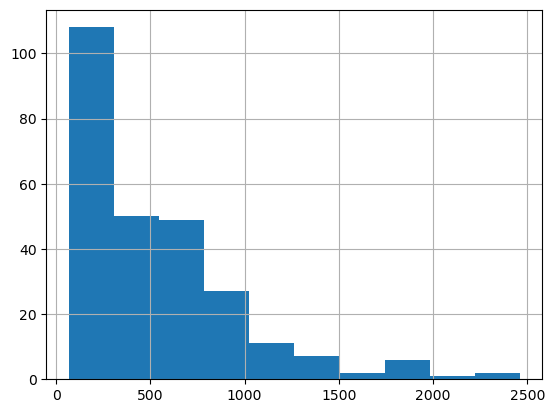

In [75]:
df['Salary'].hist()

In [76]:
# Fill missing salary values with median
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

<Axes: >

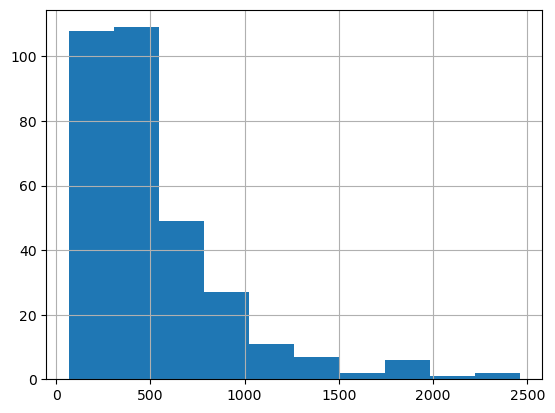

In [77]:
df['Salary'].hist()

In [78]:
# Verify shape after preprocessing
df.shape

(322, 20)

## 5. Exploratory Data Analysis (EDA)

### 5.1 Categorical Features Analysis

In [79]:
df[categorical_cols].head()

,League,Division,NewLeague
0,A,E,A
1,N,W,N
2,A,W,A
3,N,E,N
4,N,E,N


League
League
A    175
N    147
Name: count, dtype: int64
Division
Division
W    165
E    157
Name: count, dtype: int64
NewLeague
NewLeague
A    176
N    146
Name: count, dtype: int64


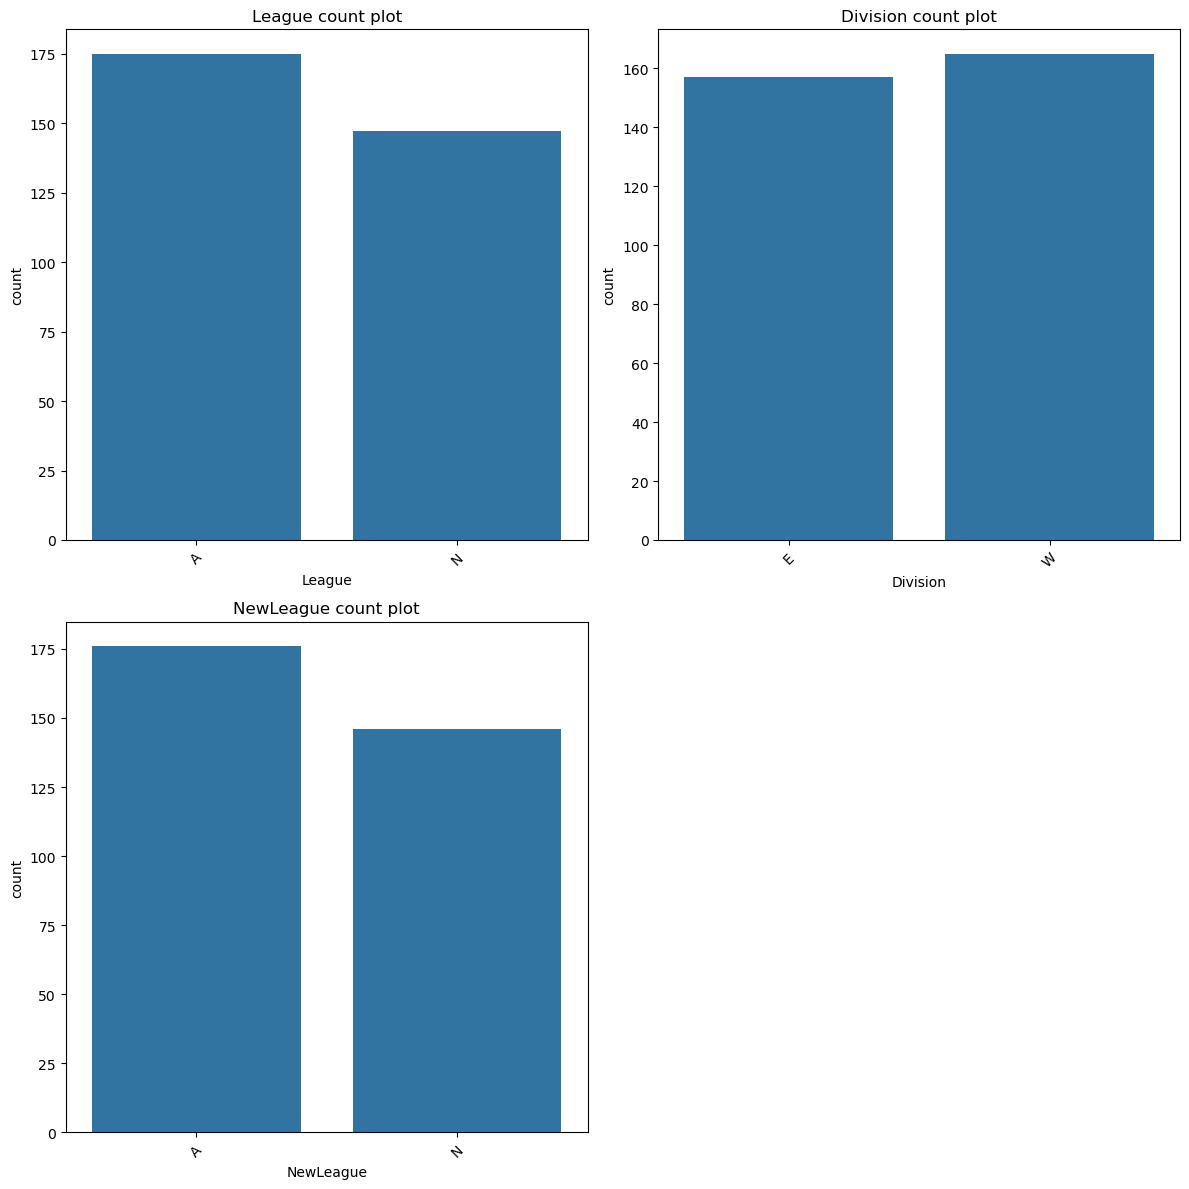

In [80]:

n = len(categorical_cols)

rows = (n // 2) + (n % 2)
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6 * rows))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    print(col)
    print(df[col].value_counts())

    sns.countplot(x=col, data=df, ax=axes[idx])
    axes[idx].set_title(f"{col} count plot")
    axes[idx].tick_params(axis='x', rotation=45)


for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 5.2 Numerical Features Analysis

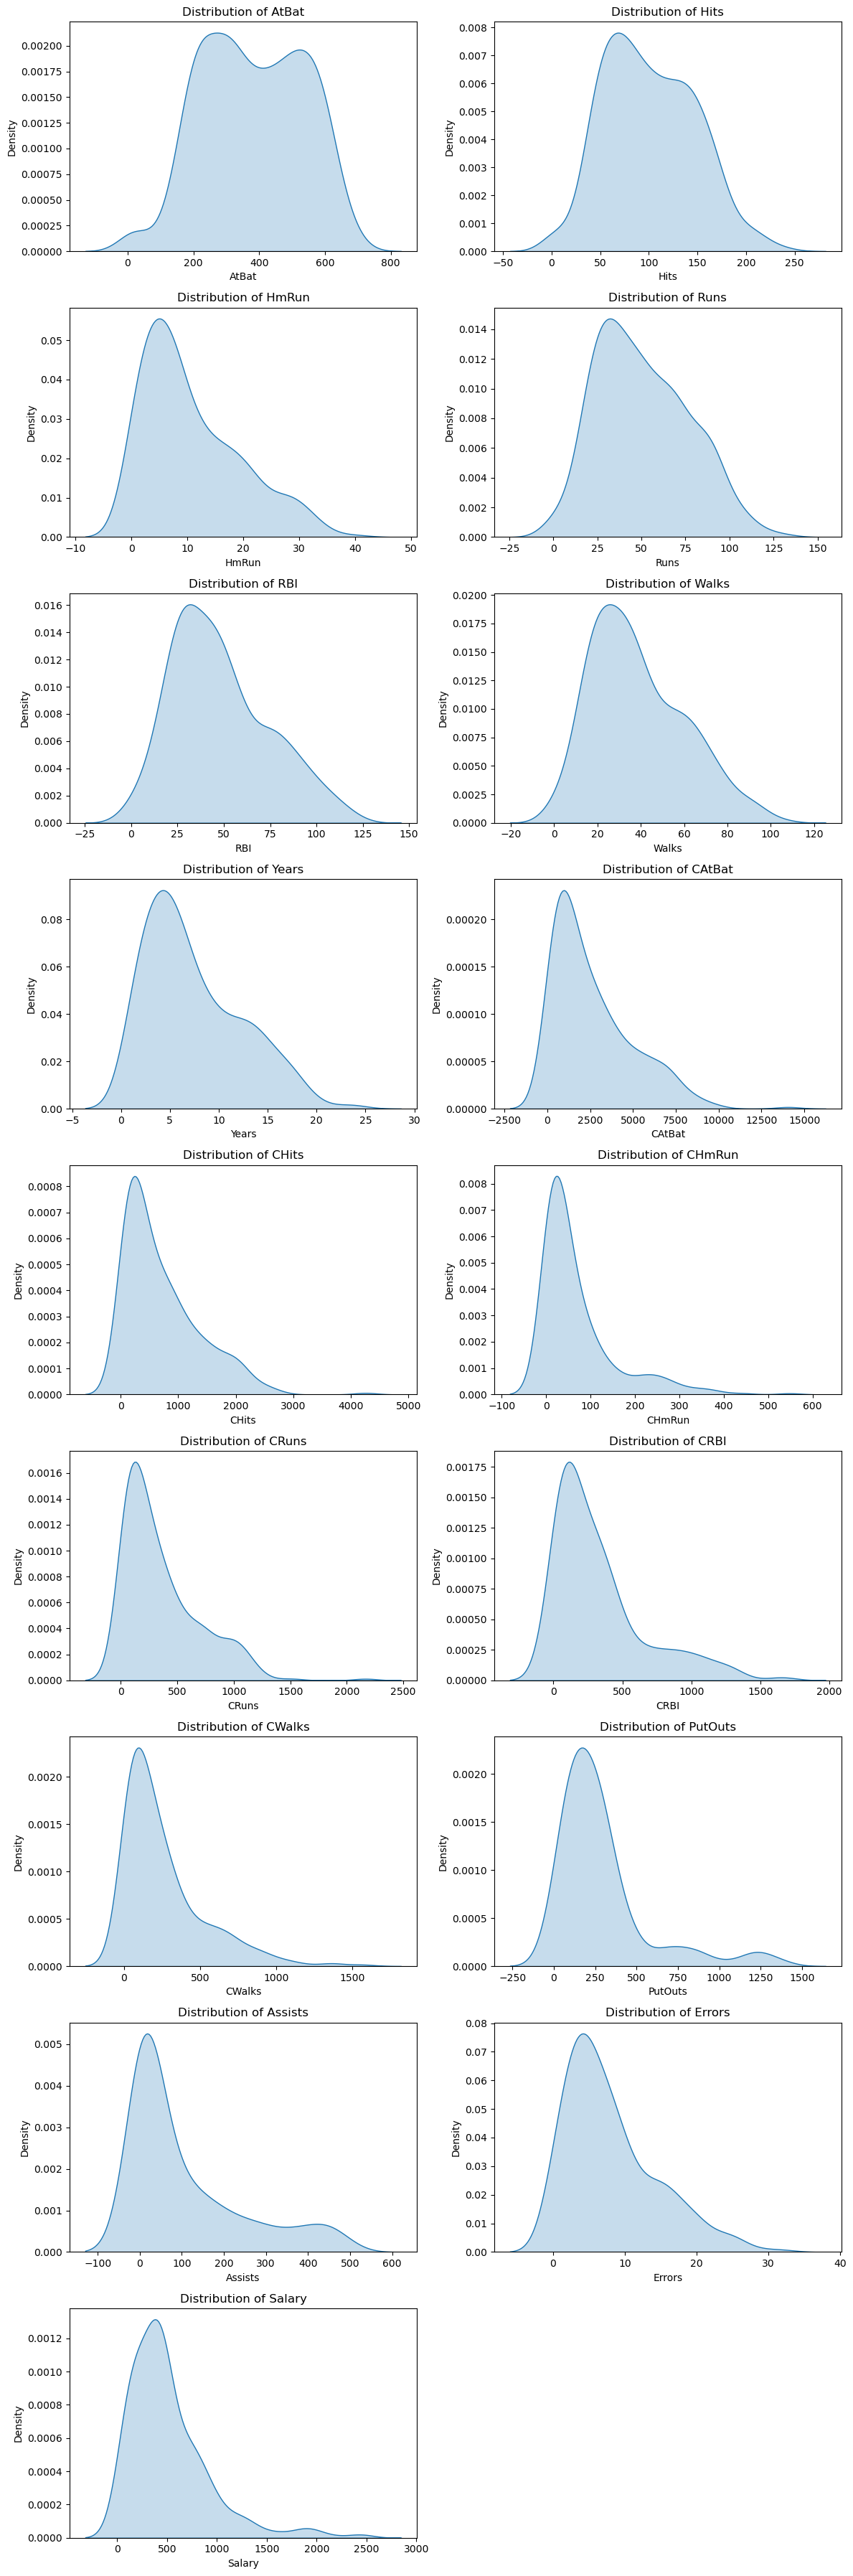

In [81]:
# Number of numerical columns
n_cols = len(numerical_cols)

# Decide grid size (e.g., 2 columns)
n_rows = (n_cols + 1) // 2

# Create subplots
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4*n_rows))
axes = axes.flatten()  # flatten to 1D for easy indexing

# Loop through numerical columns
for i, col in enumerate(numerical_cols):
    sns.kdeplot(df[col], shade=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# Hide unused subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 6 Outlier Treatment

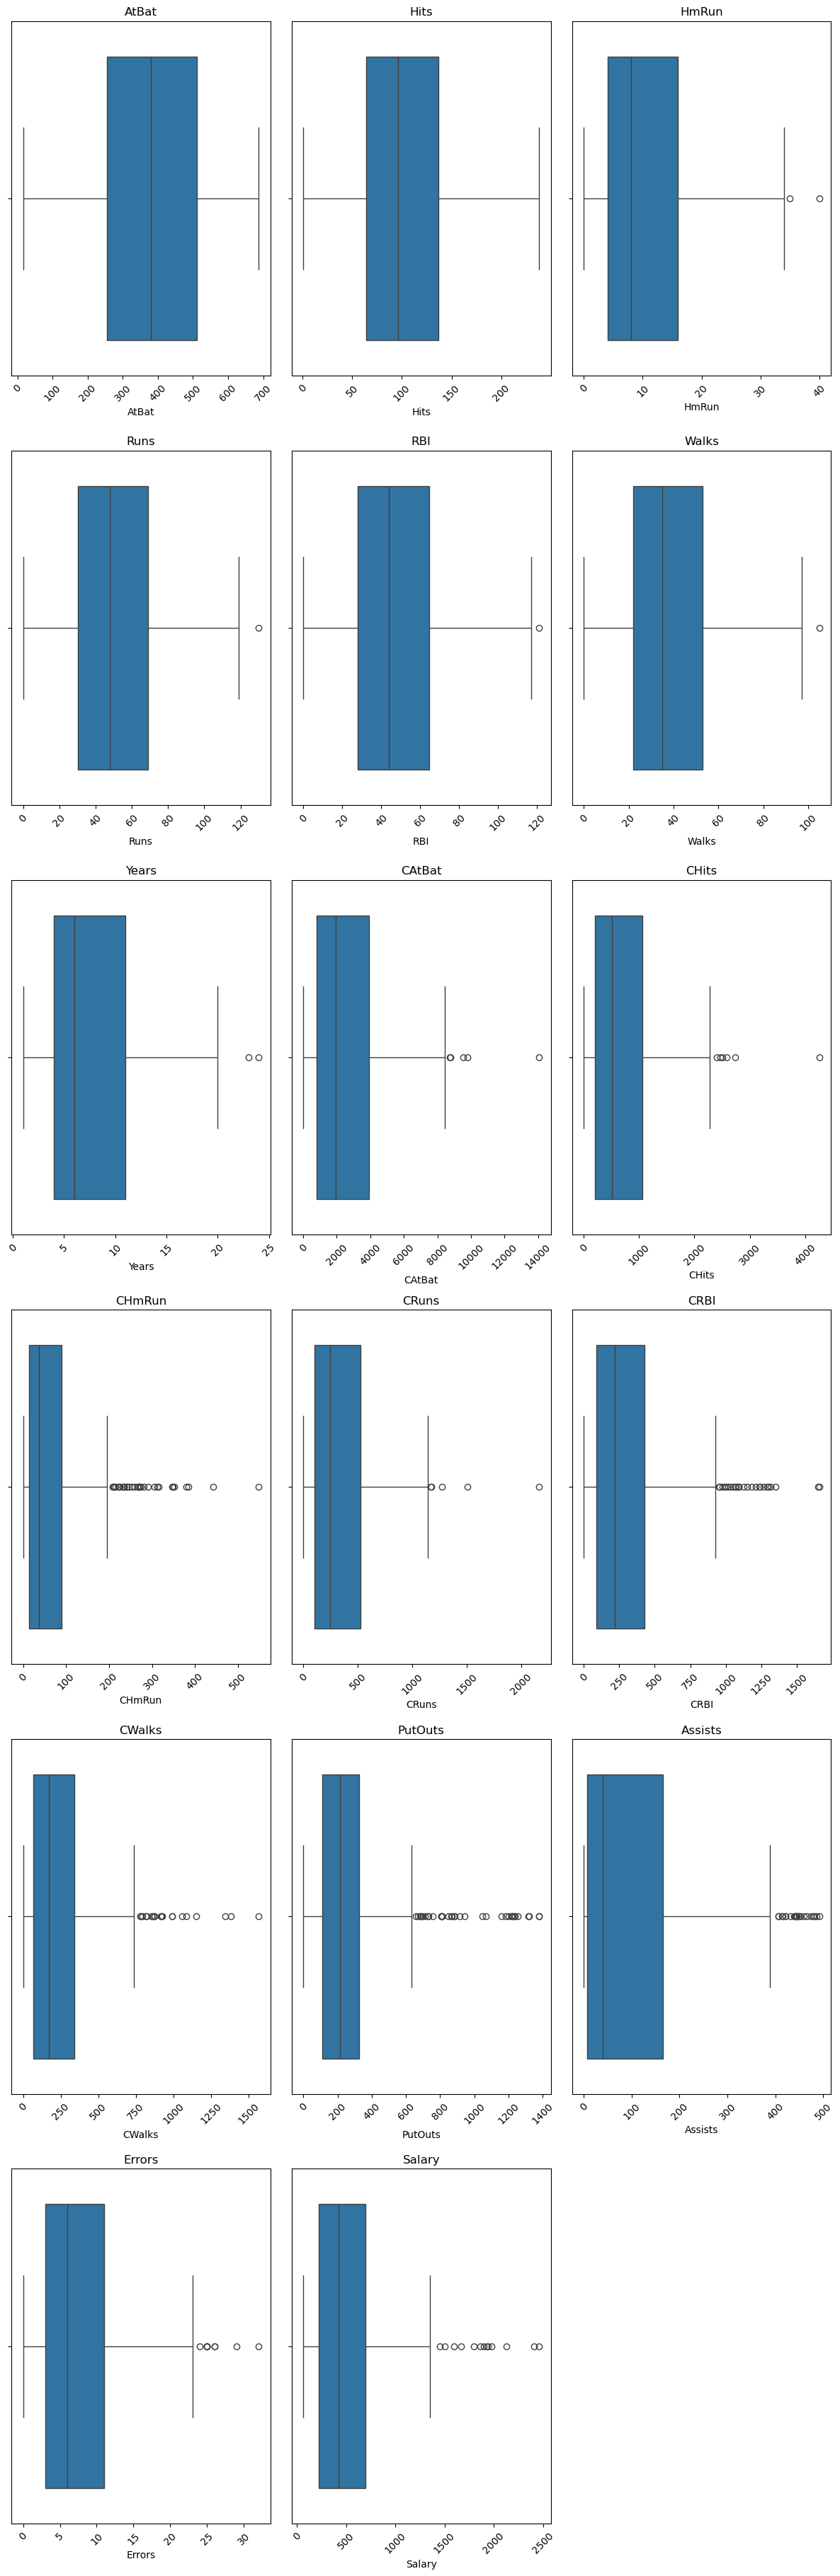

In [82]:
# Visualize outliers with boxplots
n = len(numerical_cols)

rows = (n // 2) + (n % 2)
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(12, 6 * rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    sns.boxplot(x=col, data=df, ax=axes[idx])
    axes[idx].set_title(f"{col}")
    axes[idx].tick_params(axis='x', rotation=45)


for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [83]:
from scipy.stats import skew

def clean_outliers_auto(df, out_cols):
    """
    Automatically cleans outliers column-wise using the best method.

    Methods tested:
    - No change
    - IQR capping
    - Percentile capping (1%–99%)
    - Log transform (if applicable)

    Returns:
    - Cleaned DataFrame
    """

    df_clean = df.copy()

    for col in out_cols:
        if col not in df_clean.columns:
            continue

        x = df_clean[col].dropna()

        if x.nunique() < 10:
            continue  # skip low-variance columns

        results = {}

        # ---------- 1. No change ----------
        results["none"] = skew(x)

        # ---------- 2. IQR capping ----------
        Q1, Q3 = x.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        x_iqr = x.clip(lower, upper)
        results["iqr"] = skew(x_iqr)

        # ---------- 3. Percentile capping ----------
        p1, p99 = x.quantile([0.01, 0.99])
        x_pct = x.clip(p1, p99)
        results["percentile"] = skew(x_pct)

        # ---------- 4. Log transform ----------
        if (x > 0).all():
            x_log = np.log1p(x)
            results["log"] = skew(x_log)
        else:
            results["log"] = np.inf

        # ---------- Choose best ----------
        best_method = min(results, key=lambda k: abs(results[k]))

        # ---------- Apply best ----------
        if best_method == "iqr":
            df_clean[col] = df_clean[col].clip(lower, upper)

        elif best_method == "percentile":
            df_clean[col] = df_clean[col].clip(p1, p99)

        elif best_method == "log":
            df_clean[col] = np.log1p(df_clean[col])

        # else: keep original

    return df_clean


In [84]:
out_cols = [
    'HmRun','Runs','RBI','Walks','Years',
    'CAtBat','CHits','CHmRun','CRuns',
    'CRBI','CWalks','PutOuts','Assists','Errors'
]

df_cleaned = clean_outliers_auto(df, out_cols)


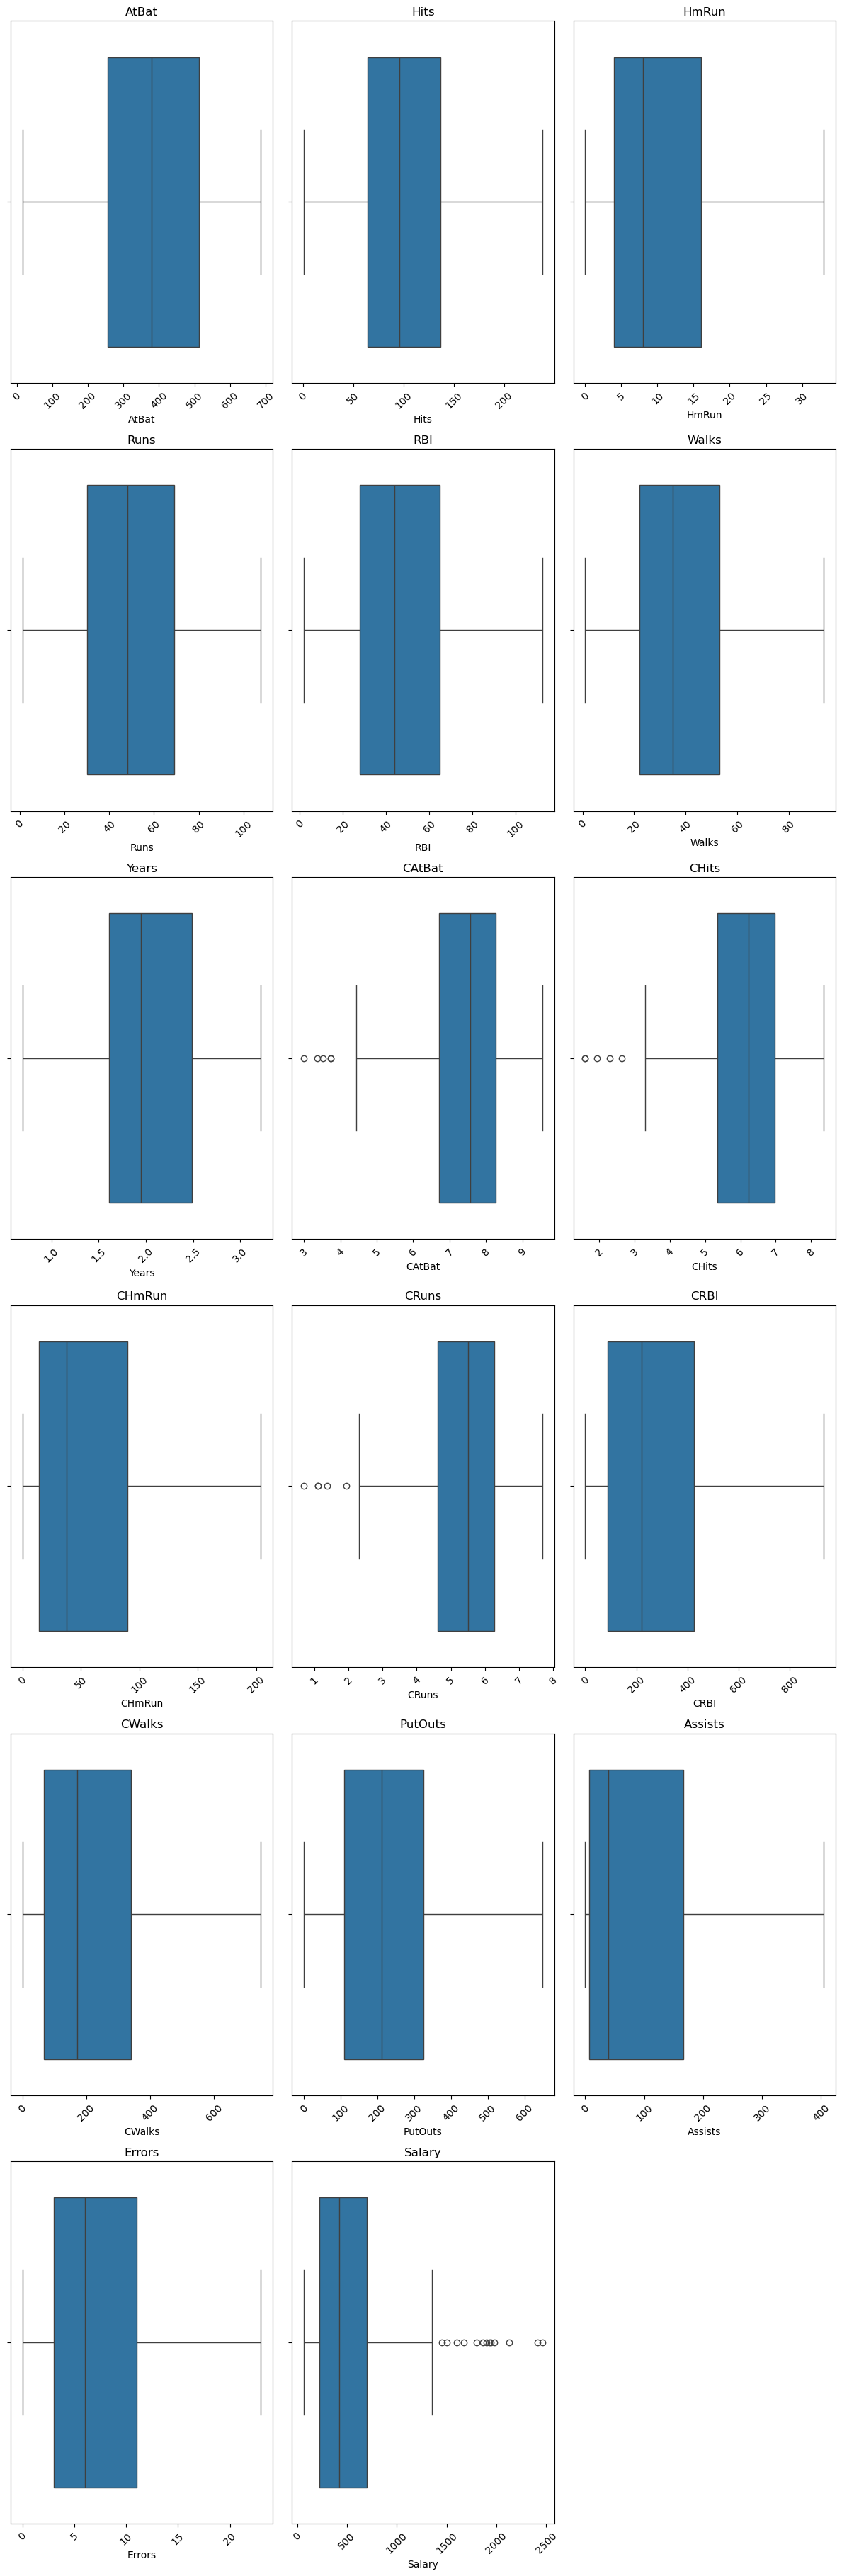

In [85]:

n = len(numerical_cols)

rows = (n // 2) + (n % 2)
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(12, 6 * rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    sns.boxplot(x=col, data=df_cleaned, ax=axes[idx])
    axes[idx].set_title(f"{col}")
    axes[idx].tick_params(axis='x', rotation=45)


for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [86]:
df_cleaned.shape

(322, 20)

In [87]:
skew_col=[]
for i in numerical_cols:
  if (df_cleaned[i].skew()>0.75) | (df_cleaned[i].skew()<-0.75):
    print(i,df_cleaned[i].skew())
    skew_col.append(i)

HmRun 0.8522959455241875
CAtBat -0.8477949985431867
CHits -0.8295793440379601
CHmRun 1.2015444772855972
CRuns -0.8354286245171
CRBI 1.0424831336916165
CWalks 1.03672411177572
PutOuts 0.9316554547783088
Assists 1.2295524581067443
Errors 0.8582013081697256
Salary 1.8736106075882106


In [88]:
skew_col.remove('Salary')

In [89]:
skew_col

['HmRun',
 'CAtBat',
 'CHits',
 'CHmRun',
 'CRuns',
 'CRBI',
 'CWalks',
 'PutOuts',
 'Assists',
 'Errors']

In [90]:
for i in skew_col:
  df_cleaned[i]=np.log1p(df[i])

## 7. Feature Relationship Analysis

### 7.1 Feature vs Target Variable
Analyzing relationship between features and salary using regression plots.

In [91]:
df_cleaned.shape

(322, 20)

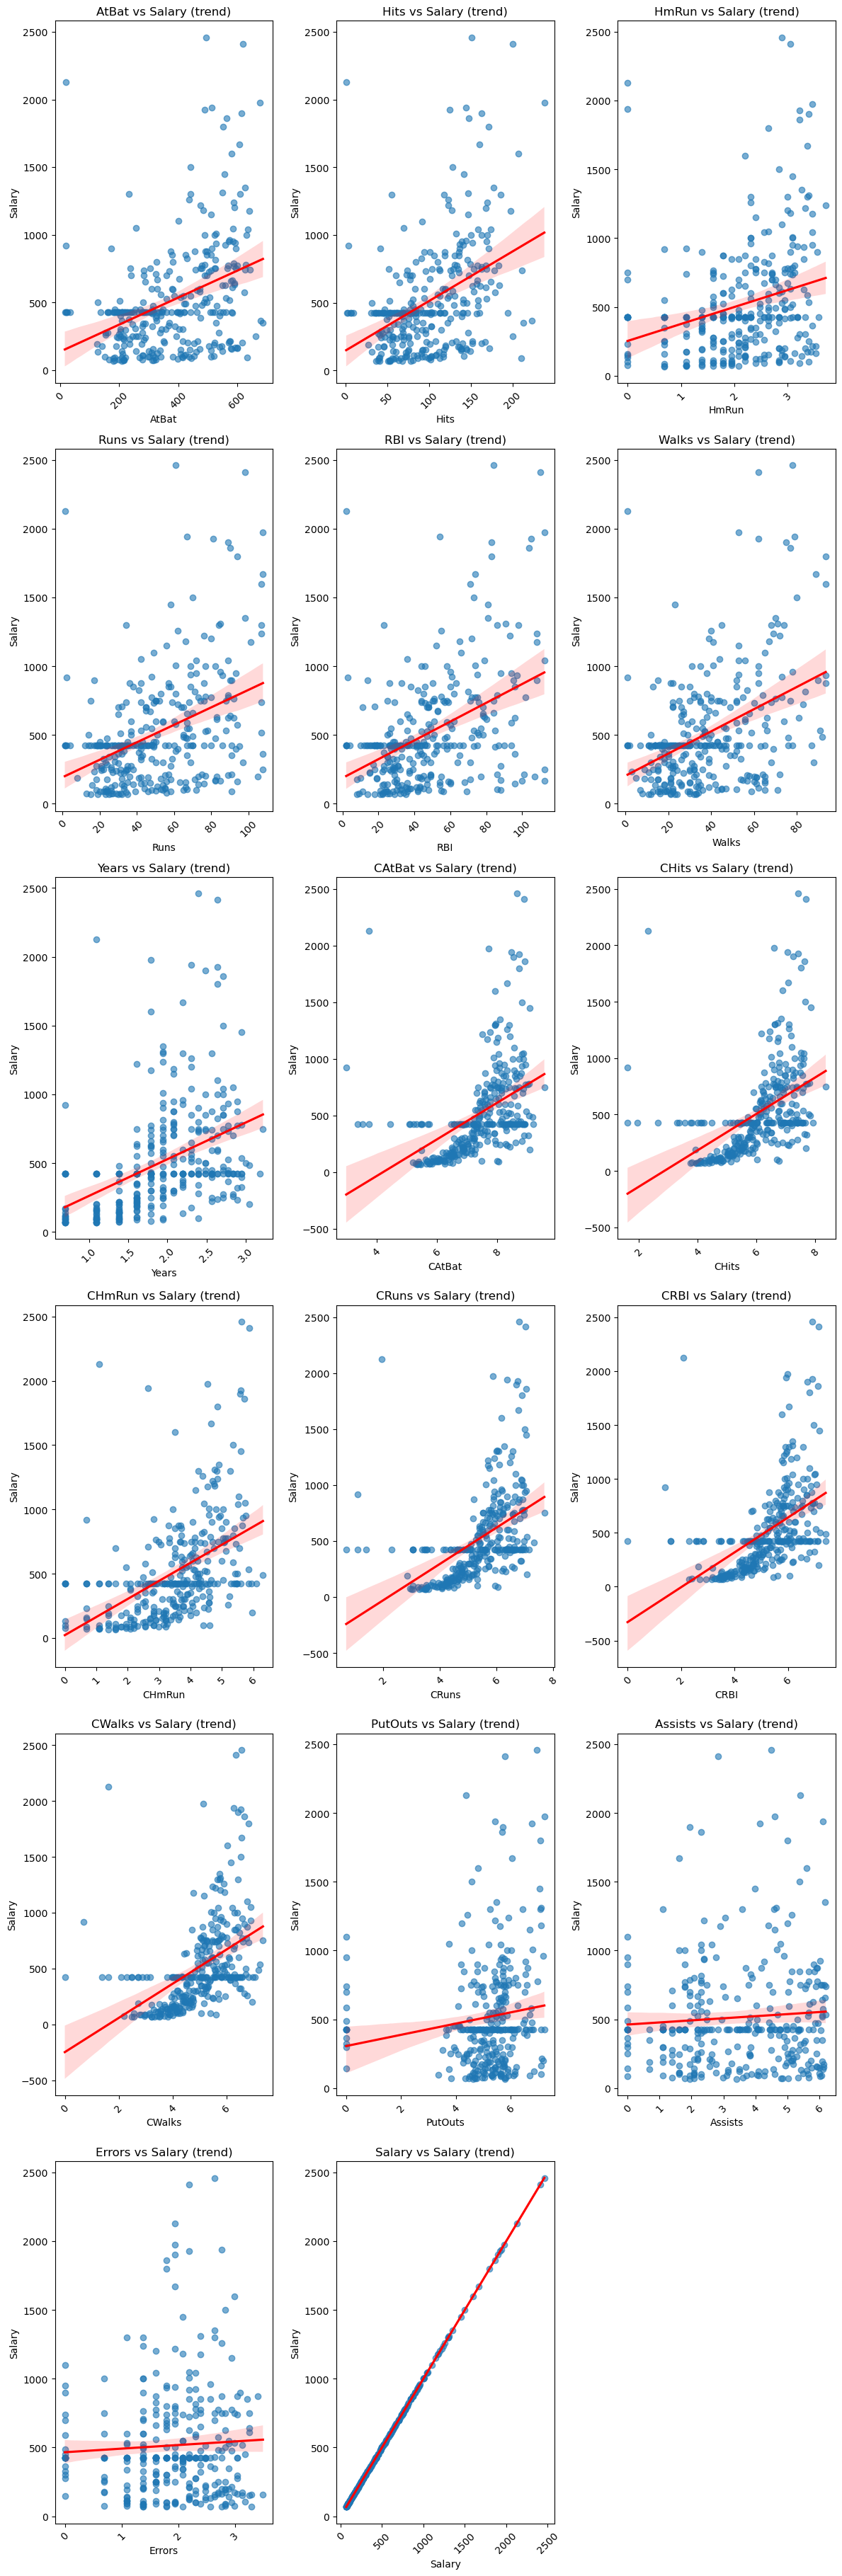

In [92]:
n = len(numerical_cols)

rows = (n // 2) + (n % 2)
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(12, 6 * rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    sns.regplot(
        data=df_cleaned,
        x=col,
        y='Salary',
        ax=axes[idx],
        scatter_kws={'alpha':0.6},
        line_kws={'color':'red'}
    )
    axes[idx].set_title(f"{col} vs Salary (trend)")
    axes[idx].tick_params(axis='x', rotation=45)

# Hide unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

we can remove assists and Errors cols because no trend follows regarding the target var

```
Assists
Errors
PutOuts
Years
```

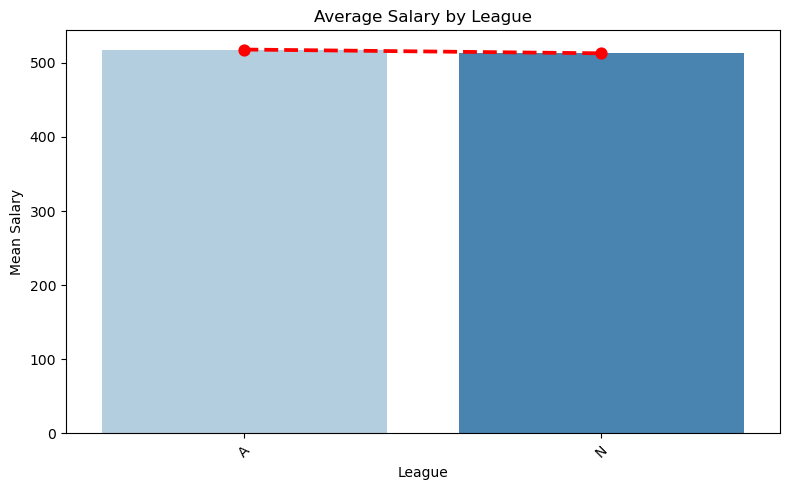

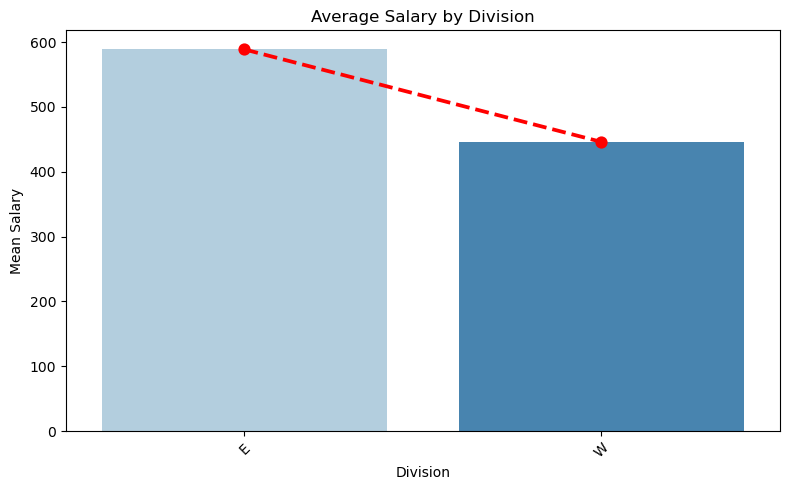

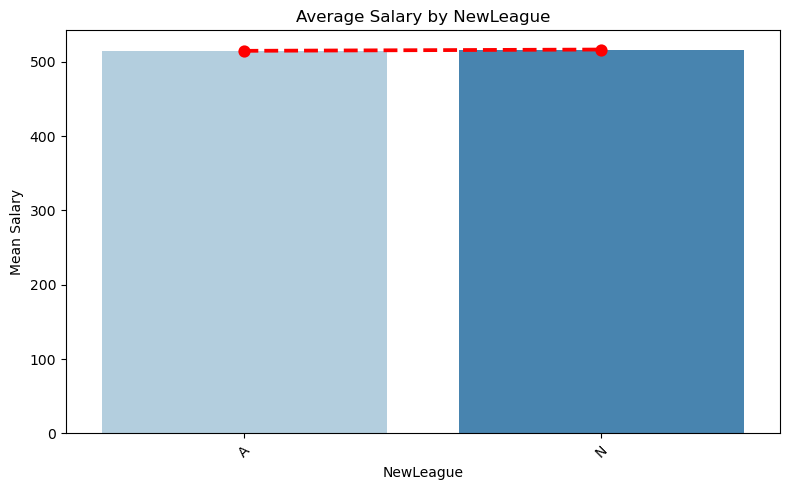

In [93]:

# Loop through categorical columns
for col in categorical_cols:
    plt.figure(figsize=(8,5))
    
    # Bar plot (mean salary per category)
    sns.barplot(x=df_cleaned[col], y=df['Salary'], estimator=np.mean, ci=None, palette="Blues")
    
    # Point plot overlay (trend line)
    sns.pointplot(x=df_cleaned[col], y=df['Salary'], estimator=np.mean, ci=None, color="red", markers="o", linestyles="--")
    
    # Formatting
    plt.title(f'Average Salary by {col}')
    plt.xticks(rotation=45)
    plt.ylabel("Mean Salary")
    plt.tight_layout()
    plt.show()

In [94]:
# df_cleaned.drop(columns=['Assists','Errors','PutOuts'],inplace=True)
# numerical_cols=df_cleaned.select_dtypes(include=np.number).columns

In [95]:
categorical_cols

Index(['League', 'Division', 'NewLeague'], dtype='object')

In [96]:
df_cleaned.columns

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'League', 'Division',
       'PutOuts', 'Assists', 'Errors', 'Salary', 'NewLeague'],
      dtype='object')

In [97]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df, cols):
    """
    Calculate VIF for given numeric columns
    """
    X = df[cols].dropna()
    X = X.select_dtypes(include=[np.number])

    vif_df = pd.DataFrame()
    vif_df["feature"] = X.columns
    vif_df["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    return vif_df.sort_values("VIF", ascending=False)


### 7.2 Multicollinearity Analysis (VIF)

In [98]:


vif_df = calculate_vif(df_cleaned, numerical_cols)


mean_vif = np.mean(vif_df['VIF'])
below_mean_vif = vif_df[vif_df['VIF'] < mean_vif]
print(below_mean_vif)

    feature         VIF
12   CWalks  592.352368
9    CHmRun  189.108969
1      Hits  177.227556
0     AtBat  164.186603
3      Runs   82.053271
6     Years   74.116177
2     HmRun   51.528383
4       RBI   41.983509
5     Walks   24.987346
15   Errors   20.813346
13  PutOuts   20.340182
14  Assists   14.037408
16   Salary    4.643574


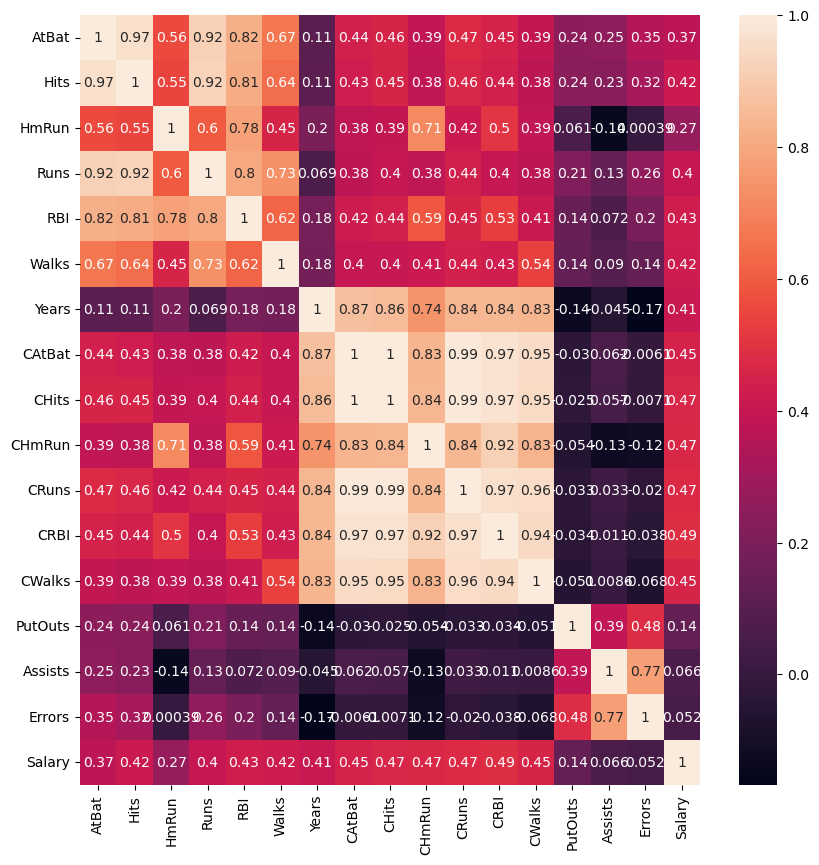

In [99]:
plt.figure(figsize=(10,10))
sns.heatmap(df_cleaned[numerical_cols].corr(),annot=True)
plt.show()

In [100]:
df_cleaned.shape

(322, 20)

## 8. Feature Engineering

### 8.1 Encode Categorical Variables

In [101]:
# # Convert boolean columns to integer (0 or 1)
# for col in ['League_N', 'Division_W', 'NewLeague_N']:
#     df_cleaned[col] = df_cleaned[col].astype(int)


In [102]:
df_cleaned.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,0.693147,30.0,29.0,14.0,0.693147,5.683580,4.204693,0.693147,3.433987,3.401197,2.708050,A,E,6.102559,3.526361,3.044522,425.0,A
1,315,81,2.079442,24.0,38.0,39.0,2.708050,8.146130,6.728629,4.248495,5.774552,6.028279,5.929589,N,W,6.450470,3.784190,2.397895,475.0,N
2,479,130,2.944439,66.0,72.0,76.0,1.386294,7.393263,6.126869,4.158883,5.416100,5.587249,5.575949,A,W,6.781058,4.418841,2.708050,480.0,A
3,496,141,3.044522,65.0,78.0,37.0,2.484907,8.635687,7.362645,5.420535,6.720220,6.732211,5.872118,N,E,5.303305,2.484907,1.386294,500.0,N
4,321,87,2.397895,39.0,42.0,30.0,1.098612,5.983936,4.624973,2.564949,3.891820,3.850148,3.526361,N,E,6.692084,3.713572,1.609438,91.5,N


In [103]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np # Import numpy for np.mean

# Select only numerical columns for VIF calculation
numerical_df_for_vif = df_cleaned[numerical_cols]

vif=pd.DataFrame()
vif['Features']=numerical_df_for_vif.columns
vif['VIF Values']=[variance_inflation_factor(numerical_df_for_vif.values,i) for i in range(len(numerical_df_for_vif.columns))]
vif[vif['VIF Values']>np.mean(vif['VIF Values'])] # Use np.mean

,Features,VIF Values
7,CAtBat,2231.297812
8,CHits,7383.076967
10,CRuns,2415.563083
11,CRBI,1556.161818


In [104]:
# Encode categorical features
df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# Convert boolean columns to integer (0 or 1)
for col in df_cleaned.select_dtypes(include='bool').columns:
    df_cleaned[col] = df_cleaned[col].astype(int)

df_cleaned.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
0,293,66,0.693147,30.0,29.0,14.0,0.693147,5.683580,4.204693,0.693147,3.433987,3.401197,2.708050,6.102559,3.526361,3.044522,425.0,0,0,0
1,315,81,2.079442,24.0,38.0,39.0,2.708050,8.146130,6.728629,4.248495,5.774552,6.028279,5.929589,6.450470,3.784190,2.397895,475.0,1,1,1
2,479,130,2.944439,66.0,72.0,76.0,1.386294,7.393263,6.126869,4.158883,5.416100,5.587249,5.575949,6.781058,4.418841,2.708050,480.0,0,1,0
3,496,141,3.044522,65.0,78.0,37.0,2.484907,8.635687,7.362645,5.420535,6.720220,6.732211,5.872118,5.303305,2.484907,1.386294,500.0,1,0,1
4,321,87,2.397895,39.0,42.0,30.0,1.098612,5.983936,4.624973,2.564949,3.891820,3.850148,3.526361,6.692084,3.713572,1.609438,91.5,1,0,1


In [105]:
# Drop high VIF feature and separate X, y
X = df_cleaned.drop(columns=['Salary','CHits'])

y = df_cleaned['Salary']
print(f"Target shape: {y.shape}")
print(f"Feature shape: {X.shape}")

Target shape: (322,)
Feature shape: (322, 18)


In [106]:
num_x = X.select_dtypes(include=np.number).columns
cat_x = X.select_dtypes(exclude=np.number).columns

In [107]:
cat_x

Index([], dtype='object')

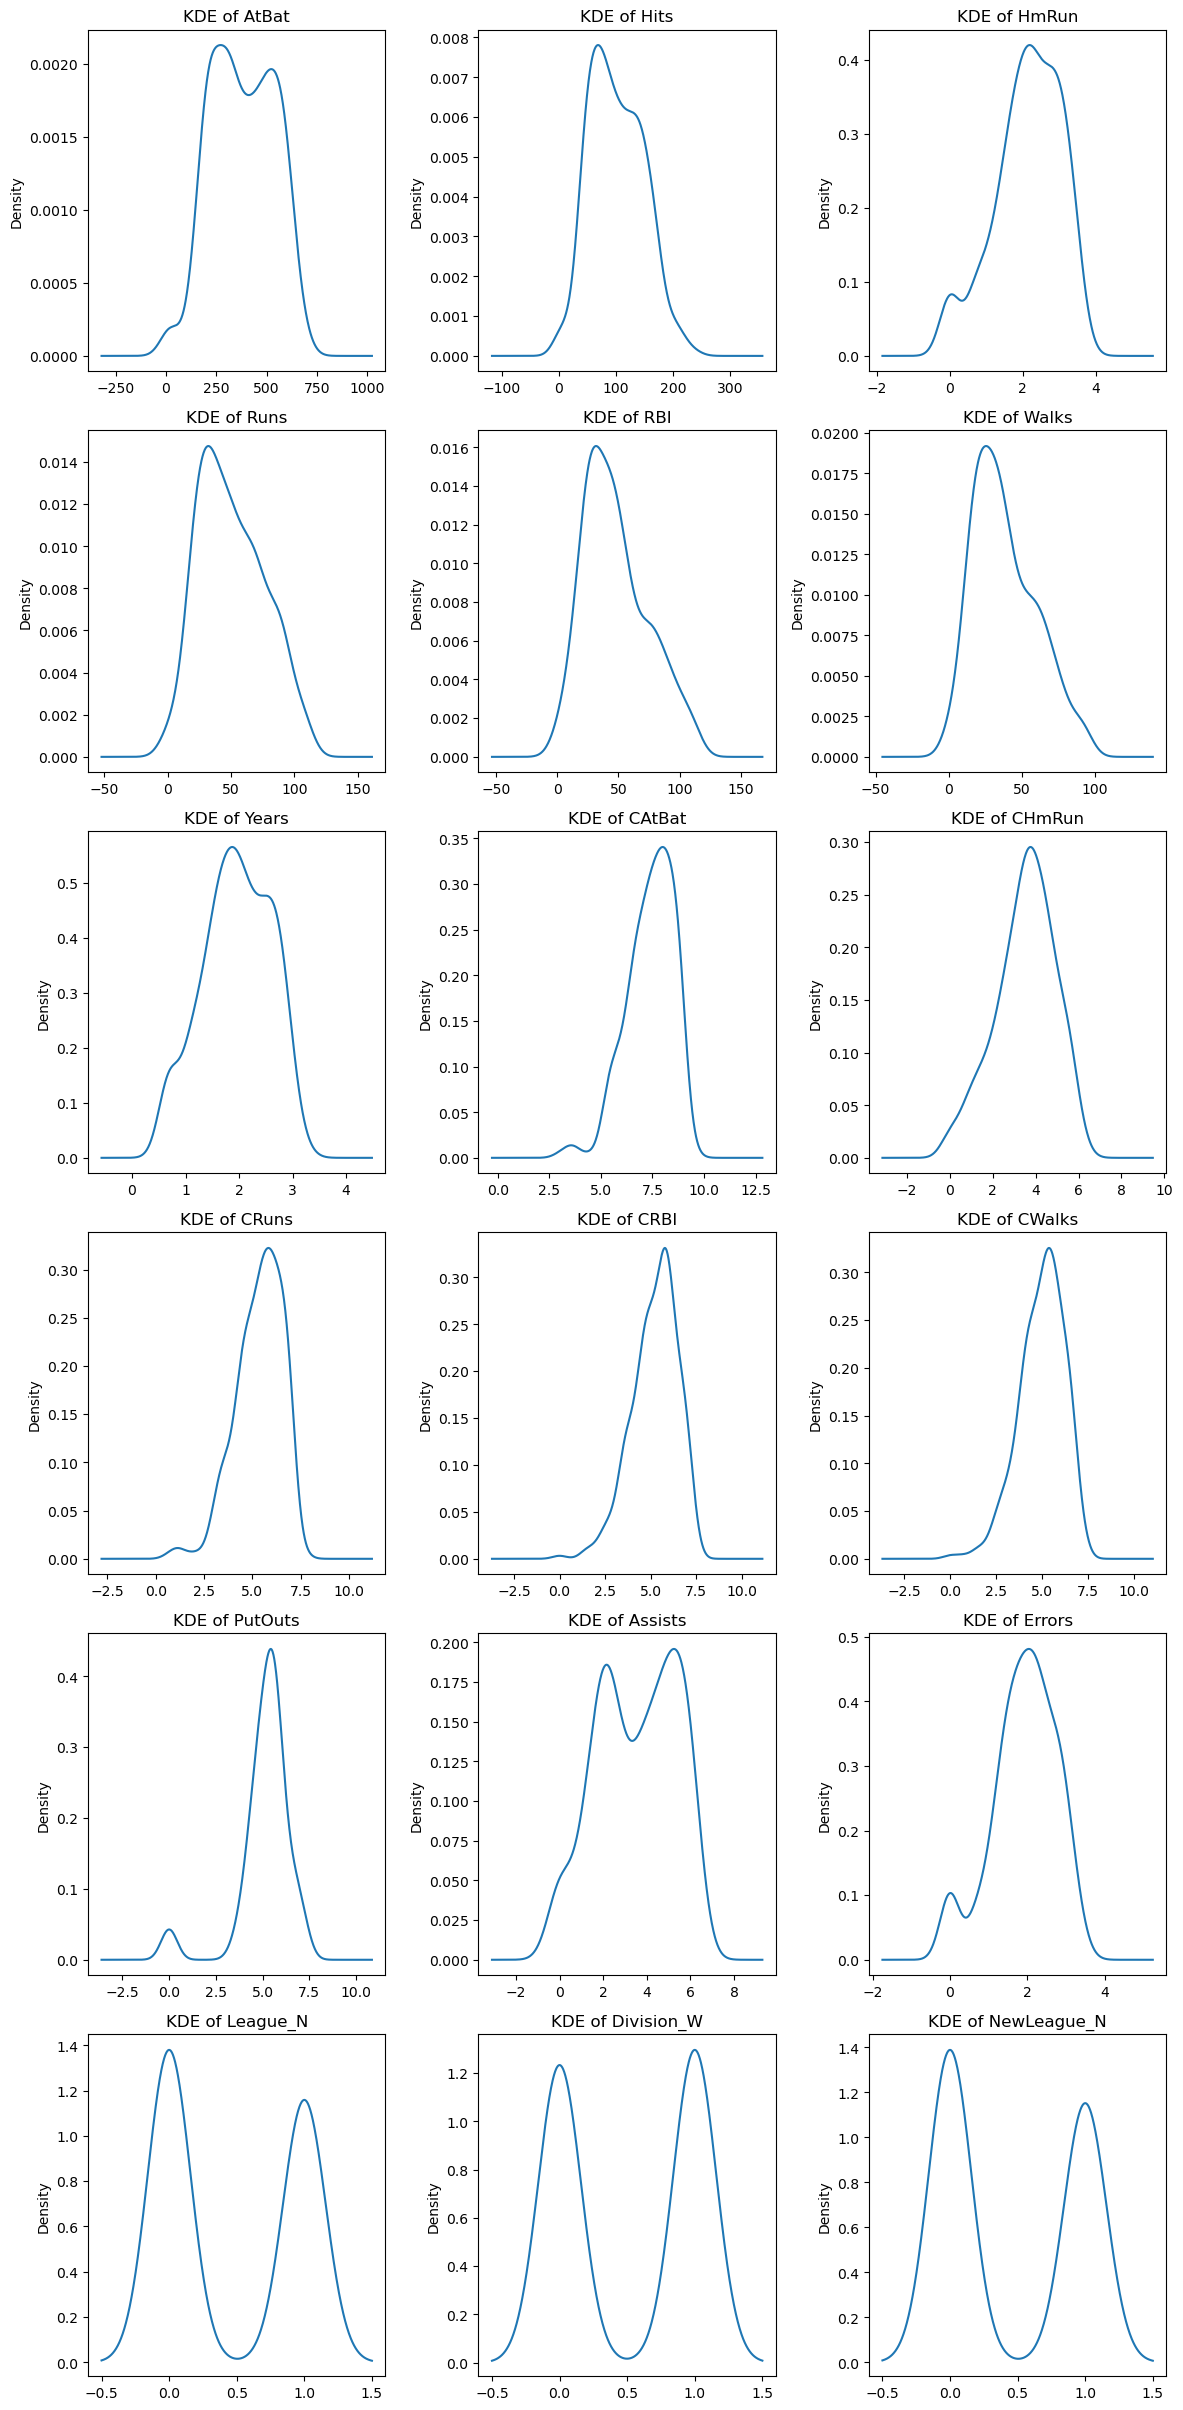

In [108]:
n = len(num_x)

# create subplots with 2 columns
rows = (n + 1) // 2   # number of rows needed
fig, axes = plt.subplots(nrows=rows, ncols=3, figsize=(12, 4*rows))

# flatten axes array for easy iteration
axes = axes.flatten()

for ax, col in zip(axes, num_x):
    df_cleaned[col].plot(kind='kde', ax=ax)
    ax.set_title(f"KDE of {col}")

# hide any unused subplot axes
for ax in axes[len(num_x):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Feature Engineering: Polynomial Features
Adding polynomial features to capture non-linear relationships and feature interactions

In [109]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

# Create polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

print(f"Original features: {X.shape[1]}")
print(f"Polynomial features: {X_poly.shape[1]}")

Original features: 18
Polynomial features: 189


### 8.2 Train-Test Split

In [110]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (257, 189)
Testing set: (65, 189)


### 8.3 Feature Selection

In [111]:
# Import SelectKBest for feature selection
from sklearn.feature_selection import SelectKBest, f_regression

# Select top 50 features based on F-statistic
selector = SelectKBest(score_func=f_regression, k=50)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

print(f"Features after selection: {X_train_selected.shape[1]}")

Features after selection: 50


### 8.4 Feature Scaling

In [112]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Scale features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("Feature scaling completed")

Feature scaling completed


### Model Training and Evaluation
Now training multiple models with proper preprocessing (Polynomial Features + Scaling)

In [113]:
# Store results
results = []

### Linear Regression

In [114]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr = lr_model.predict(X_test_scaled)

print("="*50)
print("LINEAR REGRESSION")
print("="*50)
print(f"TRAIN R2 : {r2_score(y_train, y_pred_lr_train):.4f}")
print(f"TEST R2  : {r2_score(y_test, y_pred_lr):.4f}")
print(f"TRAIN RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_lr_train)):.2f}")
print(f"TEST RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"TEST MAE  : {mean_absolute_error(y_test, y_pred_lr):.2f}")

results.append({'Model': 'Linear Regression', 'Train R2': r2_score(y_train, y_pred_lr_train), 
                'Test R2': r2_score(y_test, y_pred_lr)})

LINEAR REGRESSION
TRAIN R2 : 0.6770
TEST R2  : 0.3648
TRAIN RMSE: 227.90
TEST RMSE : 349.36
TEST MAE  : 232.17


### Ridge Regression

In [115]:
# Ridge Regression with CV
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

y_pred_ridge_train = ridge_cv.predict(X_train_scaled)
y_pred_ridge = ridge_cv.predict(X_test_scaled)

print("" + "="*50)
print("RIDGE REGRESSION WITH CV")
print("="*50)
print(f"Best alpha: {ridge_cv.alpha_}")
print(f"TRAIN R2 : {r2_score(y_train, y_pred_ridge_train):.4f}")
print(f"TEST R2  : {r2_score(y_test, y_pred_ridge):.4f}")
print(f"TRAIN RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_ridge_train)):.2f}")
print(f"TEST RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.2f}")
print(f"TEST MAE  : {mean_absolute_error(y_test, y_pred_ridge):.2f}")

results.append({'Model': 'Ridge Regression CV', 'Train R2': r2_score(y_train, y_pred_ridge_train), 'Test R2': r2_score(y_test, y_pred_ridge)})

RIDGE REGRESSION WITH CV
Best alpha: 0.1
TRAIN R2 : 0.6399
TEST R2  : 0.5559
TRAIN RMSE: 240.63
TEST RMSE : 292.12
TEST MAE  : 198.05


### Lasso Regression

In [116]:
# Lasso Regression with CV
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

y_pred_lasso_train = lasso_cv.predict(X_train_scaled)
y_pred_lasso = lasso_cv.predict(X_test_scaled)

print("" + "="*50)
print("LASSO REGRESSION WITH CV")
print("="*50)
print(f"Best alpha: {lasso_cv.alpha_}")
print(f"TRAIN R2 : {r2_score(y_train, y_pred_lasso_train):.4f}")
print(f"TEST R2  : {r2_score(y_test, y_pred_lasso):.4f}")
print(f"TRAIN RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_lasso_train)):.2f}")
print(f"TEST RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.2f}")
print(f"TEST MAE  : {mean_absolute_error(y_test, y_pred_lasso):.2f}")

results.append({'Model': 'Lasso Regression CV', 'Train R2': r2_score(y_train, y_pred_lasso_train), 'Test R2': r2_score(y_test, y_pred_lasso)})

LASSO REGRESSION WITH CV
Best alpha: 1.0
TRAIN R2 : 0.6023
TEST R2  : 0.5539
TRAIN RMSE: 252.90
TEST RMSE : 292.80
TEST MAE  : 199.05


## Lasso Regression with CV 

In [117]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Lasso Regression with Cross-Validation
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
lasso_model = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lasso_train = lasso_model.predict(X_train_scaled)
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Print results
print("" + "="*50)
print("LASSO REGRESSION (with CV)")
print("="*50)
print(f"Best Alpha: {lasso_model.alpha_:.4f}")
print(f"TRAIN R2 : {r2_score(y_train, y_pred_lasso_train):.4f}")
print(f"TEST R2  : {r2_score(y_test, y_pred_lasso):.4f}")
print(f"TRAIN RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_lasso_train)):.2f}")
print(f"TEST RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.2f}")
print(f"TEST MAE  : {mean_absolute_error(y_test, y_pred_lasso):.2f}")

# Append results to list
results.append({
    'Model': 'Lasso Regression',
    'Best Alpha': lasso_model.alpha_,
    'Train R2': r2_score(y_train, y_pred_lasso_train),
    'Test R2': r2_score(y_test, y_pred_lasso),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_lasso_train)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    'Test MAE': mean_absolute_error(y_test, y_pred_lasso)
})

LASSO REGRESSION (with CV)
Best Alpha: 1.0000
TRAIN R2 : 0.6023
TEST R2  : 0.5539
TRAIN RMSE: 252.90
TEST RMSE : 292.80
TEST MAE  : 199.05


## Ridge Regression with CV 

In [118]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Ridge Regression with Cross-Validation
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
ridgecv_model = RidgeCV(alphas=alphas, cv=5)
ridgecv_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_ridgecv_train = ridgecv_model.predict(X_train_scaled)
y_pred_ridgecv = ridgecv_model.predict(X_test_scaled)

# Print results
print("" + "="*50)
print("RIDGE REGRESSION (with CV)")
print("="*50)
print(f"Best Alpha: {ridgecv_model.alpha_:.4f}")
print(f"TRAIN R2 : {r2_score(y_train, y_pred_ridgecv_train):.4f}")
print(f"TEST R2  : {r2_score(y_test, y_pred_ridgecv):.4f}")
print(f"TRAIN RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_ridgecv_train)):.2f}")
print(f"TEST RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_ridgecv)):.2f}")
print(f"TEST MAE  : {mean_absolute_error(y_test, y_pred_ridgecv):.2f}")

# Append results to list
results.append({
    'Model': 'RidgeCV',
    'Best Alpha': ridgecv_model.alpha_,
    'Train R2': r2_score(y_train, y_pred_ridgecv_train),
    'Test R2': r2_score(y_test, y_pred_ridgecv),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_ridgecv_train)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_ridgecv)),
    'Test MAE': mean_absolute_error(y_test, y_pred_ridgecv)
})

RIDGE REGRESSION (with CV)
Best Alpha: 0.1000
TRAIN R2 : 0.6399
TEST R2  : 0.5559
TRAIN RMSE: 240.63
TEST RMSE : 292.12
TEST MAE  : 198.05


## Decison Tree Regressor 

In [119]:
from sklearn.tree import DecisionTreeRegressor

# Decision Tree Regressor
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42, min_samples_split=5, min_samples_leaf=2)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt_train = dt_model.predict(X_train_scaled)
y_pred_dt = dt_model.predict(X_test_scaled)

print("" + "="*50)
print("DECISION TREE REGRESSOR")
print("="*50)
print(f"TRAIN R2 : {r2_score(y_train, y_pred_dt_train):.4f}")
print(f"TEST R2  : {r2_score(y_test, y_pred_dt):.4f}")
print(f"TRAIN RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_dt_train)):.2f}")
print(f"TEST RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_dt)):.2f}")
print(f"TEST MAE  : {mean_absolute_error(y_test, y_pred_dt):.2f}")

results.append({'Model': 'Decision Tree', 'Train R2': r2_score(y_train, y_pred_dt_train), 
                'Test R2': r2_score(y_test, y_pred_dt)})

DECISION TREE REGRESSOR
TRAIN R2 : 0.9435
TEST R2  : 0.3916
TRAIN RMSE: 95.32
TEST RMSE : 341.94
TEST MAE  : 227.22


### Random Forest Regressor

In [120]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Random Forest Regressor (before tuning)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf_train = rf_model.predict(X_train_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)

# Print results
print("" + "="*50)
print("RANDOM FOREST REGRESSOR (Default)")
print("="*50)
print(f"TRAIN R2 : {r2_score(y_train, y_pred_rf_train):.4f}")
print(f"TEST R2  : {r2_score(y_test, y_pred_rf):.4f}")
print(f"TRAIN RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_rf_train)):.2f}")
print(f"TEST RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"TEST MAE  : {mean_absolute_error(y_test, y_pred_rf):.2f}")

# Append results to list
results.append({
    'Model': 'Random Forest (Default)',
    'Train R2': r2_score(y_train, y_pred_rf_train),
    'Test R2': r2_score(y_test, y_pred_rf),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_rf_train)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'Test MAE': mean_absolute_error(y_test, y_pred_rf)
})

RANDOM FOREST REGRESSOR (Default)
TRAIN R2 : 0.9250
TEST R2  : 0.5784
TRAIN RMSE: 109.79
TEST RMSE : 284.63
TEST MAE  : 180.60


## Gradient Boosting Regressor with Tunning

In [121]:
# Gradient Boosting Regressor with Tuning
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

gb_grid = GradientBoostingRegressor(random_state=42)
grid_search_gb = GridSearchCV(estimator=gb_grid, param_grid=param_grid_gb, cv=5, n_jobs=-1, verbose=1, scoring='r2')
grid_search_gb.fit(X_train_scaled, y_train)

best_gb_model = grid_search_gb.best_estimator_

y_pred_gb_train = best_gb_model.predict(X_train_scaled)
y_pred_gb = best_gb_model.predict(X_test_scaled)

print("" + "="*50)
print("GRADIENT BOOSTING REGRESSOR (TUNED)")
print("="*50)
print(f"Best params: {grid_search_gb.best_params_}")
print(f"TRAIN R2 : {r2_score(y_train, y_pred_gb_train):.4f}")
print(f"TEST R2  : {r2_score(y_test, y_pred_gb):.4f}")
print(f"TRAIN RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_gb_train)):.2f}")
print(f"TEST RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.2f}")
print(f"TEST MAE  : {mean_absolute_error(y_test, y_pred_gb):.2f}")

results.append({
    'Model': 'Gradient Boosting Tuned',
    'Train R2': r2_score(y_train, y_pred_gb_train),
    'Test R2': r2_score(y_test, y_pred_gb),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_gb_train)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_gb)),
    'Test MAE': mean_absolute_error(y_test, y_pred_gb)
})

Fitting 5 folds for each of 27 candidates, totalling 135 fits
GRADIENT BOOSTING REGRESSOR (TUNED)
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
TRAIN R2 : 0.9300
TEST R2  : 0.5203
TRAIN RMSE: 106.07
TEST RMSE : 303.61
TEST MAE  : 188.23


### Random Forest Regressor

In [122]:
# Random Forest Regressor with Tuning
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = RandomForestRegressor(random_state=42)
grid_search_rf = GridSearchCV(estimator=rf_grid, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=1, scoring='r2')
grid_search_rf.fit(X_train_scaled, y_train)

best_rf_model = grid_search_rf.best_estimator_

y_pred_rf_train = best_rf_model.predict(X_train_scaled)
y_pred_rf = best_rf_model.predict(X_test_scaled)

print("" + "="*50)
print("RANDOM FOREST REGRESSOR (TUNED)")
print("="*50)
print(f"Best params: {grid_search_rf.best_params_}")
print(f"TRAIN R2 : {r2_score(y_train, y_pred_rf_train):.4f}")
print(f"TEST R2  : {r2_score(y_test, y_pred_rf):.4f}")
print(f"TRAIN RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_rf_train)):.2f}")
print(f"TEST RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"TEST MAE  : {mean_absolute_error(y_test, y_pred_rf):.2f}")

results.append({
    'Model': 'Random Forest Tuned',
    'Train R2': r2_score(y_train, y_pred_rf_train),
    'Test R2': r2_score(y_test, y_pred_rf),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_rf_train)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'Test MAE': mean_absolute_error(y_test, y_pred_rf)
})

Fitting 5 folds for each of 81 candidates, totalling 405 fits
RANDOM FOREST REGRESSOR (TUNED)
Best params: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
TRAIN R2 : 0.7769
TEST R2  : 0.6903
TRAIN RMSE: 189.42
TEST RMSE : 243.96
TEST MAE  : 164.98


## XGBoost Regressor 

In [123]:

from xgboost import XGBRegressor

# XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbosity=0)
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb_train = xgb_model.predict(X_train_scaled)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("" + "="*50)
print("XGBOOST REGRESSOR")
print("="*50)
print(f"TRAIN R2 : {r2_score(y_train, y_pred_xgb_train):.4f}")
print(f"TEST R2  : {r2_score(y_test, y_pred_xgb):.4f}")
print(f"TRAIN RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_xgb_train)):.2f}")
print(f"TEST RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f}")
print(f"TEST MAE  : {mean_absolute_error(y_test, y_pred_xgb):.2f}")

results.append({
    'Model': 'XGBoost',
    'Train R2': r2_score(y_train, y_pred_xgb_train),
    'Test R2': r2_score(y_test, y_pred_xgb),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_xgb_train)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
    'Test MAE': mean_absolute_error(y_test, y_pred_xgb)
})


XGBOOST REGRESSOR
TRAIN R2 : 0.9965
TEST R2  : 0.6427
TRAIN RMSE: 23.64
TEST RMSE : 262.02
TEST MAE  : 171.90


### Advanced Linear Models with Polynomial Features to reduce underfitting

In [124]:

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV, LassoCV

poly_degree = 2

ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
lasso_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

# Ridge with polynomial features
ridge_poly = Pipeline([
    ("poly", PolynomialFeatures(degree=poly_degree, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=ridge_alphas, cv=5))
])

ridge_poly.fit(X_train_selected, y_train)
y_pred_ridge_poly_train = ridge_poly.predict(X_train_selected)
y_pred_ridge_poly = ridge_poly.predict(X_test_selected)

print("" + "="*70)
print("RIDGE REGRESSION WITH POLYNOMIAL FEATURES")
print("="*70)
print(f"Degree: {poly_degree}, Best alpha: {ridge_poly.named_steps['ridge'].alpha_}")
print(f"TRAIN R2 : {r2_score(y_train, y_pred_ridge_poly_train):.4f}")
print(f"TEST R2  : {r2_score(y_test, y_pred_ridge_poly):.4f}")
print(f"TRAIN RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_ridge_poly_train)):.2f}")
print(f"TEST RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_ridge_poly)):.2f}")
print(f"TEST MAE  : {mean_absolute_error(y_test, y_pred_ridge_poly):.2f}")

results.append({
    'Model': f'Ridge Poly (deg={poly_degree})',
    'Train R2': r2_score(y_train, y_pred_ridge_poly_train),
    'Test R2': r2_score(y_test, y_pred_ridge_poly),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_ridge_poly_train)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_ridge_poly)),
    'Test MAE': mean_absolute_error(y_test, y_pred_ridge_poly)
})

# Lasso with polynomial features
lasso_poly = Pipeline([
    ("poly", PolynomialFeatures(degree=poly_degree, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(alphas=lasso_alphas, cv=5, max_iter=20000))
])

lasso_poly.fit(X_train_selected, y_train)
y_pred_lasso_poly_train = lasso_poly.predict(X_train_selected)
y_pred_lasso_poly = lasso_poly.predict(X_test_selected)

print("" + "="*70)
print("LASSO REGRESSION WITH POLYNOMIAL FEATURES")
print("="*70)
print(f"Degree: {poly_degree}, Best alpha: {lasso_poly.named_steps['lasso'].alpha_}")
print(f"TRAIN R2 : {r2_score(y_train, y_pred_lasso_poly_train):.4f}")
print(f"TEST R2  : {r2_score(y_test, y_pred_lasso_poly):.4f}")
print(f"TRAIN RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_lasso_poly_train)):.2f}")
print(f"TEST RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lasso_poly)):.2f}")
print(f"TEST MAE  : {mean_absolute_error(y_test, y_pred_lasso_poly):.2f}")

results.append({
    'Model': f'Lasso Poly (deg={poly_degree})',
    'Train R2': r2_score(y_train, y_pred_lasso_poly_train),
    'Test R2': r2_score(y_test, y_pred_lasso_poly),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_lasso_poly_train)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lasso_poly)),
    'Test MAE': mean_absolute_error(y_test, y_pred_lasso_poly)
})

RIDGE REGRESSION WITH POLYNOMIAL FEATURES
Degree: 2, Best alpha: 10.0
TRAIN R2 : 0.6997
TEST R2  : 0.5450
TRAIN RMSE: 219.76
TEST RMSE : 295.69
TEST MAE  : 194.59
LASSO REGRESSION WITH POLYNOMIAL FEATURES
Degree: 2, Best alpha: 1.0
TRAIN R2 : 0.7035
TEST R2  : 0.5632
TRAIN RMSE: 218.34
TEST RMSE : 289.73
TEST MAE  : 194.27


### Residual Analysis for Best Model

### Hyperparameter Tuning: Random Forest
Using GridSearchCV to find optimal hyperparameters for Random Forest

In [125]:
# One-cell Stacking Regressor pipeline with evaluation and results logging

from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Base estimators
stack_base_estimators = [
    ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 13), cv=5)),
    ("lasso", LassoCV(alphas=np.logspace(-3, 1, 9), cv=5, max_iter=30000)),
    ("rf", RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=4,
        random_state=42
    ))
]

# Final meta-learner
stack_final_estimator = RidgeCV(alphas=np.logspace(-3, 3, 13), cv=5)

# Full stacking pipeline
stacking_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("stack", StackingRegressor(
        estimators=stack_base_estimators,
        final_estimator=stack_final_estimator,
        n_jobs=-1,
        passthrough=False
    ))
])

# Fit model
stacking_model.fit(X_train_selected, y_train)

# Predictions
y_train_pred_stack = stacking_model.predict(X_train_selected)
y_test_pred_stack = stacking_model.predict(X_test_selected)

# Metrics
stack_train_r2 = r2_score(y_train, y_train_pred_stack)
stack_test_r2 = r2_score(y_test, y_test_pred_stack)
stack_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_stack))
stack_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_stack))
stack_test_mae = mean_absolute_error(y_test, y_test_pred_stack)

# Print summary
print("" + "="*70)
print("STACKING REGRESSOR (Ridge + Lasso + RF, poly=2)")
print("="*70)
print(f"Train R²   : {stack_train_r2:.4f}")
print(f"Test R²    : {stack_test_r2:.4f}")
print(f"Train RMSE : {stack_train_rmse:.2f}")
print(f"Test RMSE  : {stack_test_rmse:.2f}")
print(f"Test MAE   : {stack_test_mae:.2f}")
print("="*70)

# Append to results
results.append({
    "Model": "Stacking (Ridge+Lasso+RF, poly=2)",
    "Train R2": stack_train_r2,
    "Test R2": stack_test_r2,
    "Train RMSE": stack_train_rmse,
    "Test RMSE": stack_test_rmse,
    "Test MAE": stack_test_mae
})

STACKING REGRESSOR (Ridge + Lasso + RF, poly=2)
Train R²   : 0.7712
Test R²    : 0.6027
Train RMSE : 191.80
Test RMSE  : 276.30
Test MAE   : 177.44


Using best model for residual analysis: Random Forest Tuned


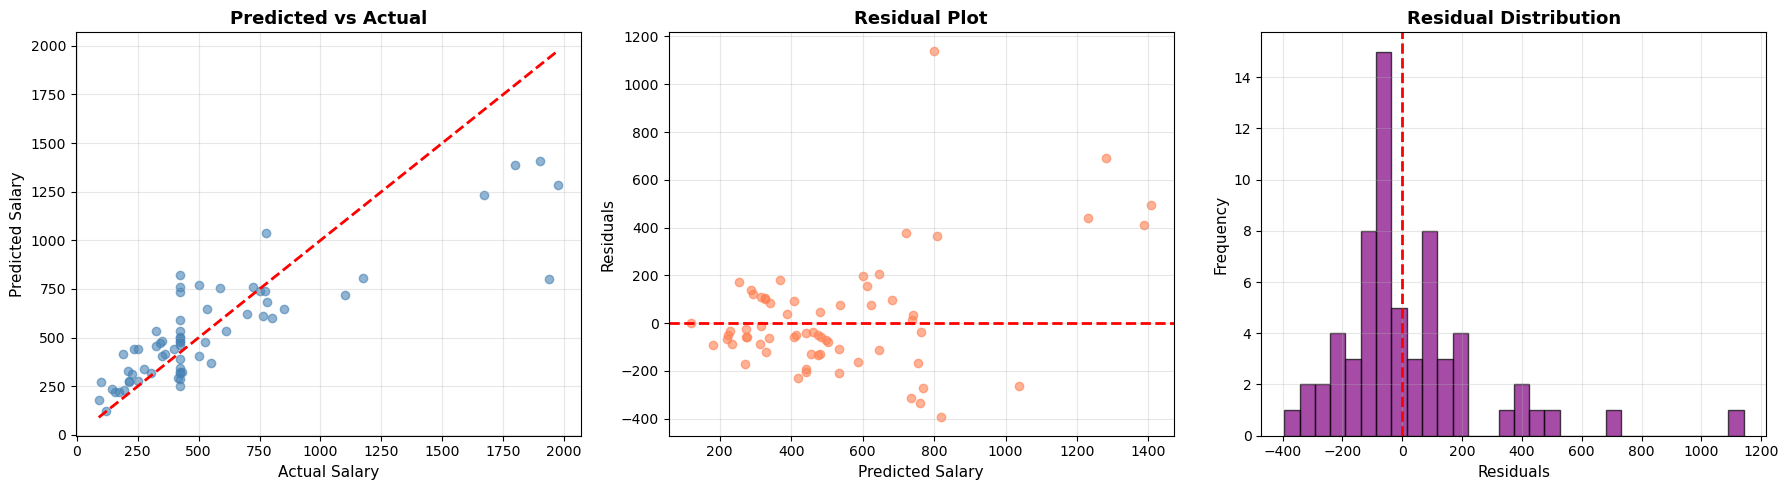

Residual Statistics:
Mean Residual: 18.50
Std Residual: 243.26
Min Residual: -394.66
Max Residual: 1140.58


In [126]:
# Residual analysis for best-performing model

import pandas as pd



# Build results_df and pick best model by Test R2

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by='Test R2', ascending=False).reset_index(drop=True)

best_model_name = results_df.iloc[0]['Model']

print(f"Using best model for residual analysis: {best_model_name}")



# Choose predictions based on best_model_name

if 'Random Forest (Tuned)' in best_model_name:

    y_pred_best_model = best_rf.predict(X_test_scaled)

    y_pred_train_best = best_rf.predict(X_train_scaled)

elif 'Gradient Boosting' in best_model_name:

    y_pred_best_model = y_pred_gb

    y_pred_train_best = y_pred_gb_train

elif 'XGBoost' in best_model_name:

    y_pred_best_model = y_pred_xgb

    y_pred_train_best = y_pred_xgb_train

else:

    # Fallback: use tuned Random Forest if specific handler is missing

    y_pred_best_model = best_rf.predict(X_test_scaled)

    y_pred_train_best = best_rf.predict(X_train_scaled)



residuals = y_test - y_pred_best_model



fig, axes = plt.subplots(1, 3, figsize=(18, 5))



# Plot 1: Predicted vs Actual

axes[0].scatter(y_test, y_pred_best_model, alpha=0.6, color='steelblue')

axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

axes[0].set_xlabel('Actual Salary', fontsize=11)

axes[0].set_ylabel('Predicted Salary', fontsize=11)

axes[0].set_title('Predicted vs Actual', fontsize=13, fontweight='bold')

axes[0].grid(alpha=0.3)



# Plot 2: Residual Plot

axes[1].scatter(y_pred_best_model, residuals, alpha=0.6, color='coral')

axes[1].axhline(y=0, color='red', linestyle='--', lw=2)

axes[1].set_xlabel('Predicted Salary', fontsize=11)

axes[1].set_ylabel('Residuals', fontsize=11)

axes[1].set_title('Residual Plot', fontsize=13, fontweight='bold')

axes[1].grid(alpha=0.3)



# Plot 3: Residual Distribution

axes[2].hist(residuals, bins=30, color='purple', alpha=0.7, edgecolor='black')

axes[2].axvline(x=0, color='red', linestyle='--', lw=2)

axes[2].set_xlabel('Residuals', fontsize=11)

axes[2].set_ylabel('Frequency', fontsize=11)

axes[2].set_title('Residual Distribution', fontsize=13, fontweight='bold')

axes[2].grid(alpha=0.3)



plt.tight_layout()

plt.show()



print("Residual Statistics:")

print(f"Mean Residual: {np.mean(residuals):.2f}")

print(f"Std Residual: {np.std(residuals):.2f}")

print(f"Min Residual: {np.min(residuals):.2f}")

print(f"Max Residual: {np.max(residuals):.2f}")

### Visualization

### Model Comparison Summary

### Feature Importance Analysis

In [128]:
# Save best model to disk for deployment
import os
import pandas as pd
from joblib import dump

# Ensure results exist
if 'results' not in globals() or not results:
    raise ValueError("No results found. Run model training cells before saving the best model.")

# Build results_df and pick best model by highest Test R2
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Test R2', ascending=False).reset_index(drop=True)
best_model_name = results_df.iloc[0]['Model']
print(f"Best model based on Test R2: {best_model_name}")
# Decide which fitted object to save based on best_model_name
model_to_save = None

try:
    if 'Stacking' in best_model_name and 'stacking_model' in globals():
        model_to_save = stacking_model
    elif 'Ridge Poly (deg=3)' in best_model_name and 'ridge_poly3' in globals():
        model_to_save = ridge_poly3
    elif 'Lasso Poly (deg=3)' in best_model_name and 'lasso_poly3' in globals():
        model_to_save = lasso_poly3
    elif 'Random Forest (Tuned)' in best_model_name and 'best_rf' in globals():
        model_to_save = best_rf
    elif 'Ridge Poly' in best_model_name and 'ridge_poly' in globals():
        model_to_save = ridge_poly
    elif 'Lasso Poly' in best_model_name and 'lasso_poly' in globals():
        model_to_save = lasso_poly
    else:
        # Sensible fallback: tuned Random Forest if available
        if 'best_rf' in globals():
            print("Falling back to tuned Random Forest for saving.")
            model_to_save = best_rf
        else:
            raise ValueError("Could not determine a model object to save for best_model_name = " + str(best_model_name))

    os.makedirs('models', exist_ok=True)
    model_path = os.path.join('models', 'best_model.joblib')
    dump(model_to_save, model_path)
    print(f"Saved best model object to {model_path}")
except Exception as e:
    print("Error while saving best model:", e)

Best model based on Test R2: Random Forest Tuned
Falling back to tuned Random Forest for saving.
Saved best model object to models\best_model.joblib


## 1. Import Libraries

## 3. Data Exploration

### 4.1 Handle Missing Values

### 4.2 Statistical Summary

<Axes: >

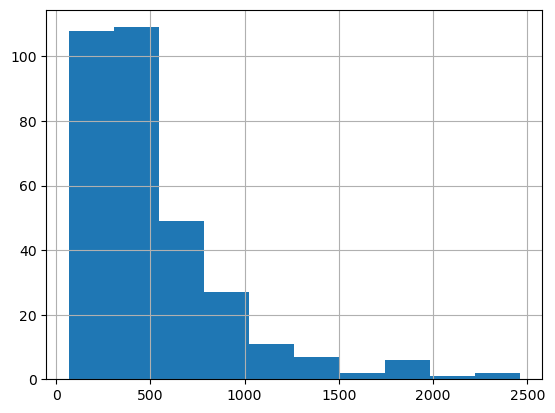

In [ ]:
df['Salary'].hist()

In [ ]:
df[categorical_cols].head()

,League,Division,NewLeague
0,A,E,A
1,N,W,N
2,A,W,A
3,N,E,N
4,N,E,N


In [83]:
from scipy.stats import skew

def clean_outliers_auto(df, out_cols):
    """
    Automatically cleans outliers column-wise using the best method.

    Methods tested:
    - No change
    - IQR capping
    - Percentile capping (1%–99%)
    - Log transform (if applicable)

    Returns:
    - Cleaned DataFrame
    """

    df_clean = df.copy()

    for col in out_cols:
        if col not in df_clean.columns:
            continue

        x = df_clean[col].dropna()

        if x.nunique() < 10:
            continue  # skip low-variance columns

        results = {}

        # ---------- 1. No change ----------
        results["none"] = skew(x)

        # ---------- 2. IQR capping ----------
        Q1, Q3 = x.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        x_iqr = x.clip(lower, upper)
        results["iqr"] = skew(x_iqr)

        # ---------- 3. Percentile capping ----------
        p1, p99 = x.quantile([0.01, 0.99])
        x_pct = x.clip(p1, p99)
        results["percentile"] = skew(x_pct)

        # ---------- 4. Log transform ----------
        if (x > 0).all():
            x_log = np.log1p(x)
            results["log"] = skew(x_log)
        else:
            results["log"] = np.inf

        # ---------- Choose best ----------
        best_method = min(results, key=lambda k: abs(results[k]))

        # ---------- Apply best ----------
        if best_method == "iqr":
            df_clean[col] = df_clean[col].clip(lower, upper)

        elif best_method == "percentile":
            df_clean[col] = df_clean[col].clip(p1, p99)

        elif best_method == "log":
            df_clean[col] = np.log1p(df_clean[col])

        # else: keep original

    return df_clean


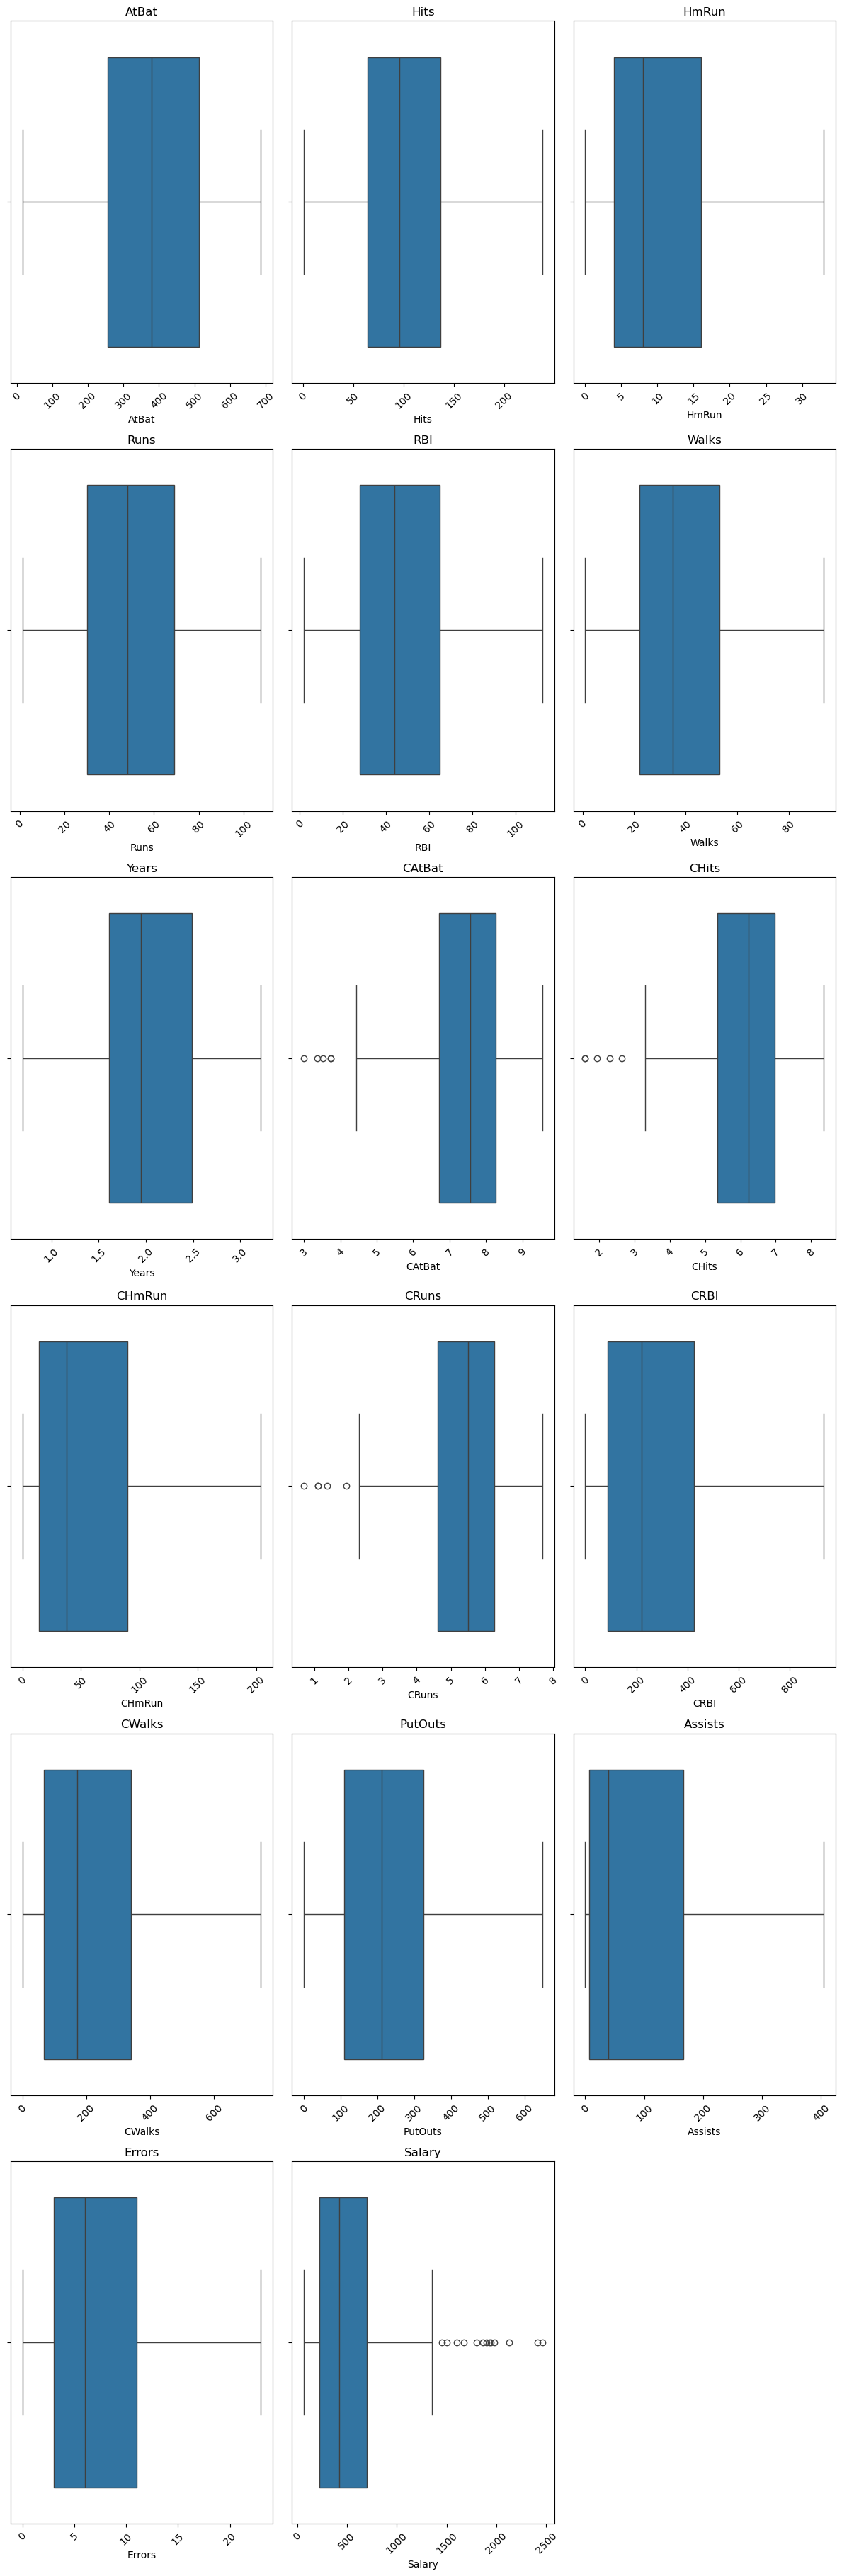

In [85]:

n = len(numerical_cols)

rows = (n // 2) + (n % 2)
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(12, 6 * rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    sns.boxplot(x=col, data=df_cleaned, ax=axes[idx])
    axes[idx].set_title(f"{col}")
    axes[idx].tick_params(axis='x', rotation=45)


for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [87]:
skew_col=[]
for i in numerical_cols:
  if (df_cleaned[i].skew()>0.75) | (df_cleaned[i].skew()<-0.75):
    print(i,df_cleaned[i].skew())
    skew_col.append(i)

HmRun 0.8522959455241875
CAtBat -0.8477949985431867
CHits -0.8295793440379601
CHmRun 1.2015444772855972
CRuns -0.8354286245171
CRBI 1.0424831336916165
CWalks 1.03672411177572
PutOuts 0.9316554547783088
Assists 1.2295524581067443
Errors 0.8582013081697256
Salary 1.8736106075882106


In [89]:
skew_col

['HmRun',
 'CAtBat',
 'CHits',
 'CHmRun',
 'CRuns',
 'CRBI',
 'CWalks',
 'PutOuts',
 'Assists',
 'Errors']

## 7. Feature Relationship Analysis

In [91]:
df_cleaned.shape

(322, 20)

we can remove assists and Errors cols because no trend follows regarding the target var

```
Assists
Errors
PutOuts
Years
```

In [94]:
# df_cleaned.drop(columns=['Assists','Errors','PutOuts'],inplace=True)
# numerical_cols=df_cleaned.select_dtypes(include=np.number).columns

In [96]:
df_cleaned.columns

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'League', 'Division',
       'PutOuts', 'Assists', 'Errors', 'Salary', 'NewLeague'],
      dtype='object')

### 7.2 Multicollinearity Analysis (VIF)

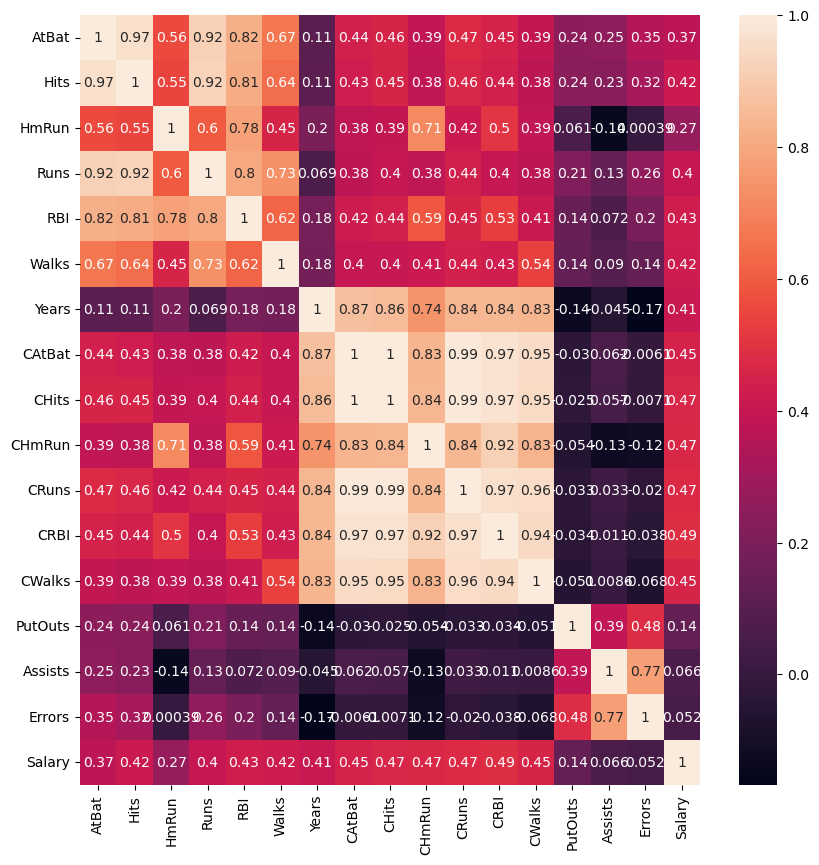

In [99]:
plt.figure(figsize=(10,10))
sns.heatmap(df_cleaned[numerical_cols].corr(),annot=True)
plt.show()

## 8. Feature Engineering

In [101]:
# # Convert boolean columns to integer (0 or 1)
# for col in ['League_N', 'Division_W', 'NewLeague_N']:
#     df_cleaned[col] = df_cleaned[col].astype(int)


In [103]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np # Import numpy for np.mean

# Select only numerical columns for VIF calculation
numerical_df_for_vif = df_cleaned[numerical_cols]

vif=pd.DataFrame()
vif['Features']=numerical_df_for_vif.columns
vif['VIF Values']=[variance_inflation_factor(numerical_df_for_vif.values,i) for i in range(len(numerical_df_for_vif.columns))]
vif[vif['VIF Values']>np.mean(vif['VIF Values'])] # Use np.mean

,Features,VIF Values
7,CAtBat,2231.297812
8,CHits,7383.076967
10,CRuns,2415.563083
11,CRBI,1556.161818


In [105]:
# Drop high VIF feature and separate X, y
X = df_cleaned.drop(columns=['Salary','CHits'])

y = df_cleaned['Salary']
print(f"Target shape: {y.shape}")
print(f"Feature shape: {X.shape}")

Target shape: (322,)
Feature shape: (322, 18)


In [107]:
cat_x

Index([], dtype='object')

### Feature Engineering: Polynomial Features
Adding polynomial features to capture non-linear relationships and feature interactions

### 8.2 Train-Test Split

### 8.3 Feature Selection

### 8.4 Feature Scaling

### Model Training and Evaluation
Now training multiple models with proper preprocessing (Polynomial Features + Scaling)

### Linear Regression

### Ridge Regression

### Lasso Regression

## Lasso Regression with CV 

## Ridge Regression with CV 

## Decison Tree Regressor 

### Random Forest Regressor

## Gradient Boosting Regressor with Tunning

## XGBoost Regressor 

### Residual Analysis for Best Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Define the base model
rf_grid = RandomForestRegressor(random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='r2'
)


grid_search.fit(X_train_scaled, y_train)

# Best parameters and CV score
print("" + "="*50)
print("RANDOM FOREST REGRESSOR (GridSearchCV)")
print("="*50)
print(f"Best CV Score: {grid_search.best_score_:.4f}")
print(f"Best parameters found: {grid_search.best_params_}")

# Get the best model
best_rf = grid_search.best_estimator_

# Predictions
y_pred_rf_tuned_train = best_rf.predict(X_train_scaled)
y_pred_rf_tuned = best_rf.predict(X_test_scaled)

print(f"TRAIN R2 : {r2_score(y_train, y_pred_rf_tuned_train):.4f}")
print(f"TEST R2  : {r2_score(y_test, y_pred_rf_tuned):.4f}")
print(f"TRAIN RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_rf_tuned_train)):.2f}")
print(f"TEST RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)):.2f}")
print(f"TEST MAE  : {mean_absolute_error(y_test, y_pred_rf_tuned):.2f}")

# Append results
results.append({
    'Model': 'Random Forest (Tuned)',
    'Train R2': r2_score(y_train, y_pred_rf_tuned_train),
    'Test R2': r2_score(y_test, y_pred_rf_tuned),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_rf_tuned_train)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)),
    'Test MAE': mean_absolute_error(y_test, y_pred_rf_tuned)
})

### Visualization

### Model Comparison Summary

### Feature Importance Analysis

In [ ]:
# Save best model to disk for deployment
import os
import pandas as pd
from joblib import dump

# Ensure results exist
if 'results' not in globals() or not results:
    raise ValueError("No results found. Run model training cells before saving the best model.")

# Build results_df and pick best model by highest Test R2
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Test R2', ascending=False).reset_index(drop=True)
best_model_name = results_df.iloc[0]['Model']
print(f"Best model based on Test R2: {best_model_name}")
# Decide which fitted object to save based on best_model_name
model_to_save = None

try:
    if 'Stacking' in best_model_name and 'stacking_model' in globals():
        model_to_save = stacking_model
    elif 'Ridge Poly (deg=3)' in best_model_name and 'ridge_poly3' in globals():
        model_to_save = ridge_poly3
    elif 'Lasso Poly (deg=3)' in best_model_name and 'lasso_poly3' in globals():
        model_to_save = lasso_poly3
    elif 'Random Forest (Tuned)' in best_model_name and 'best_rf' in globals():
        model_to_save = best_rf
    elif 'Ridge Poly' in best_model_name and 'ridge_poly' in globals():
        model_to_save = ridge_poly
    elif 'Lasso Poly' in best_model_name and 'lasso_poly' in globals():
        model_to_save = lasso_poly
    else:
        # Sensible fallback: tuned Random Forest if available
        if 'best_rf' in globals():
            print("Falling back to tuned Random Forest for saving.")
            model_to_save = best_rf
        else:
            raise ValueError("Could not determine a model object to save for best_model_name = " + str(best_model_name))

    os.makedirs('models', exist_ok=True)
    model_path = os.path.join('models', 'best_model.joblib')
    dump(model_to_save, model_path)
    print(f"Saved best model object to {model_path}")
except Exception as e:
    print("Error while saving best model:", e)

## 1. Import Libraries

## 3. Data Exploration

### 4.1 Handle Missing Values

### 4.2 Statistical Summary

<Axes: >

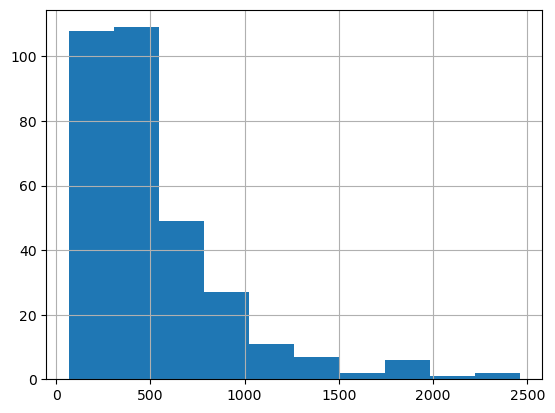

In [11]:
df['Salary'].hist()

In [13]:
df[categorical_cols].head()

,League,Division,NewLeague
0,A,E,A
1,N,W,N
2,A,W,A
3,N,E,N
4,N,E,N


## 6 Outlier Treatment

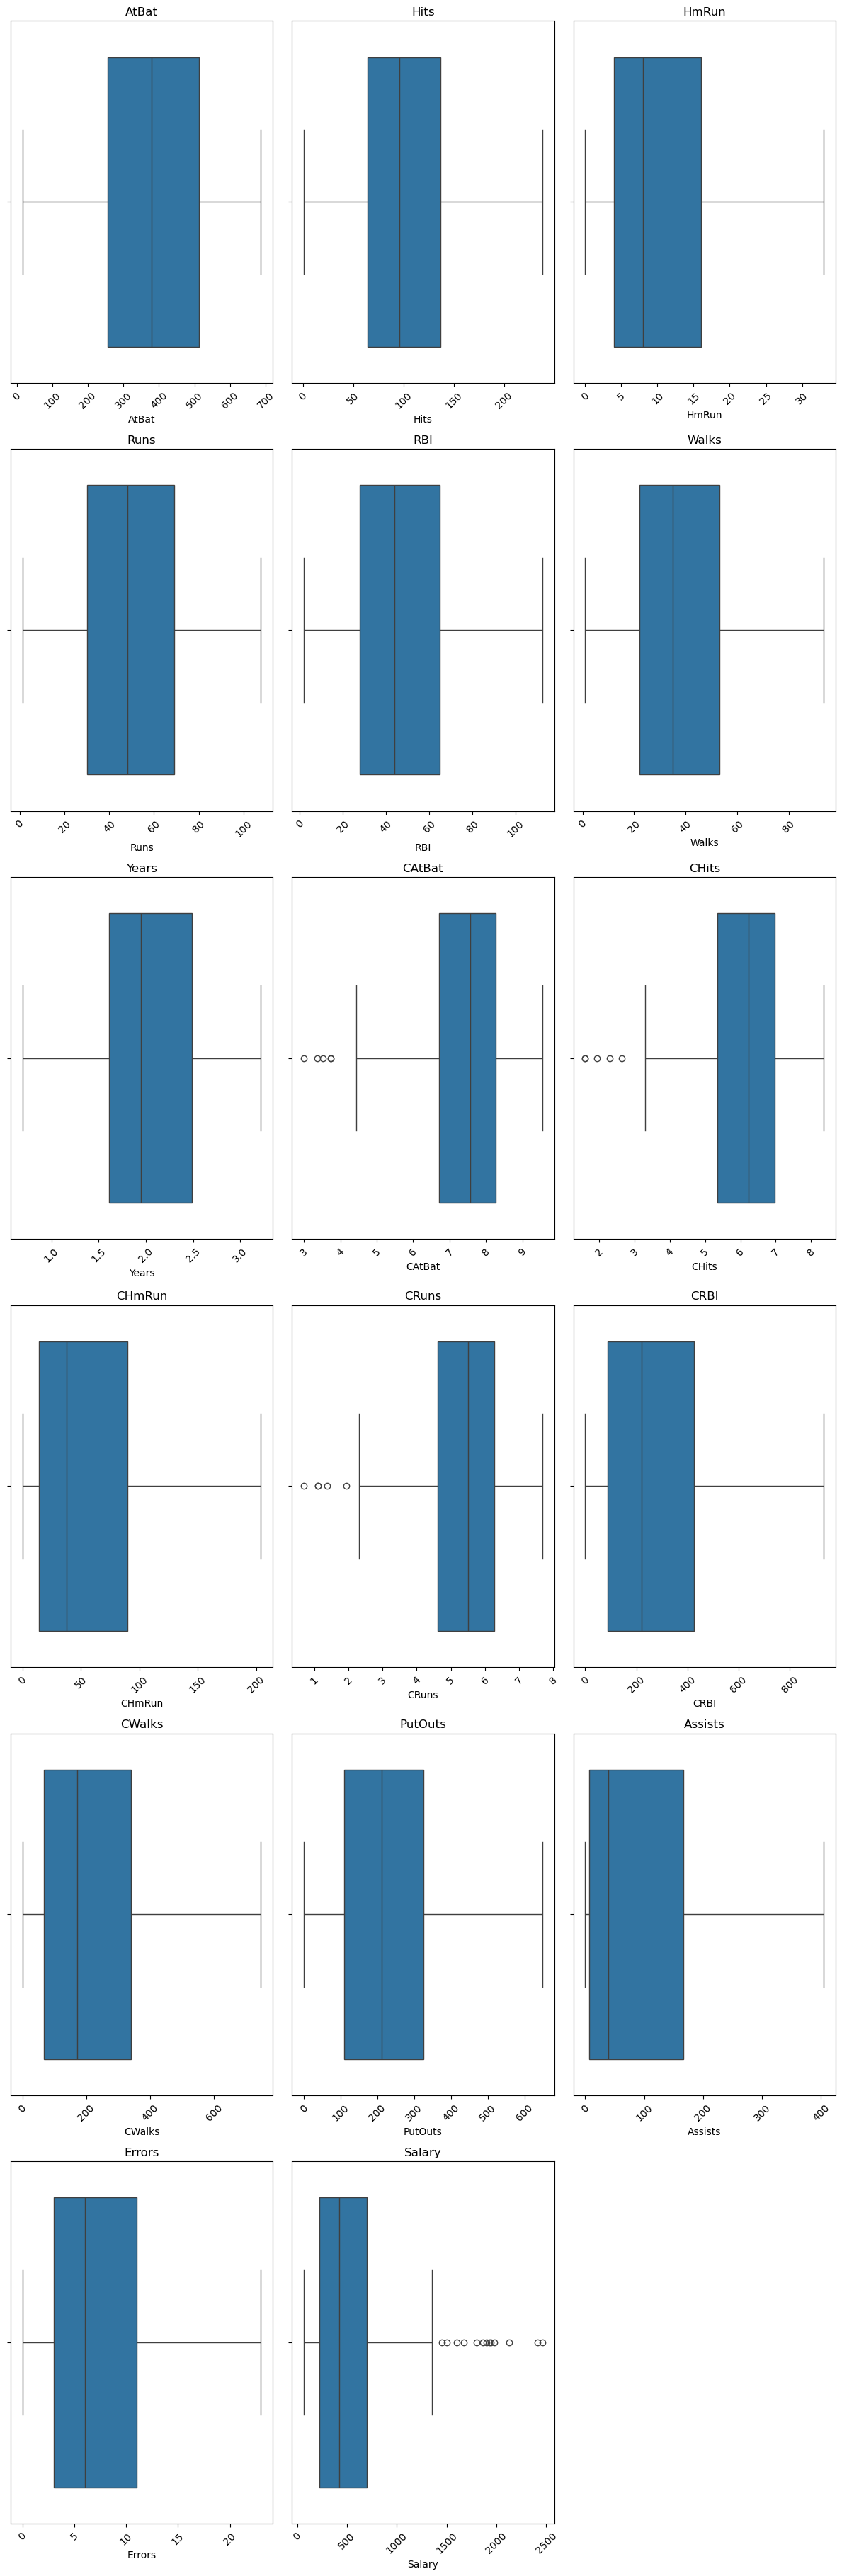

In [19]:

n = len(numerical_cols)

rows = (n // 2) + (n % 2)
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(12, 6 * rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    sns.boxplot(x=col, data=df_cleaned, ax=axes[idx])
    axes[idx].set_title(f"{col}")
    axes[idx].tick_params(axis='x', rotation=45)


for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [23]:
skew_col

['HmRun',
 'CAtBat',
 'CHits',
 'CHmRun',
 'CRuns',
 'CRBI',
 'CWalks',
 'PutOuts',
 'Assists',
 'Errors']

In [25]:
df_cleaned.shape

(322, 20)

In [28]:
# df_cleaned.drop(columns=['Assists','Errors','PutOuts'],inplace=True)
# numerical_cols=df_cleaned.select_dtypes(include=np.number).columns

### 7.2 Multicollinearity Analysis (VIF)

## 8. Feature Engineering

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np # Import numpy for np.mean

# Select only numerical columns for VIF calculation
numerical_df_for_vif = df_cleaned[numerical_cols]

vif=pd.DataFrame()
vif['Features']=numerical_df_for_vif.columns
vif['VIF Values']=[variance_inflation_factor(numerical_df_for_vif.values,i) for i in range(len(numerical_df_for_vif.columns))]
vif[vif['VIF Values']>np.mean(vif['VIF Values'])] # Use np.mean

,Features,VIF Values
7,CAtBat,2231.297812
8,CHits,7383.076967
10,CRuns,2415.563083
11,CRBI,1556.161818


In [41]:
cat_x

Index([], dtype='object')

### 8.2 Train-Test Split

### 8.4 Feature Scaling

### Linear Regression

### Lasso Regression

## Ridge Regression with CV 

### Random Forest Regressor

### Random Forest Regressor

### Advanced Linear Models with Polynomial Features to reduce underfitting

In [59]:
# One-cell Stacking Regressor pipeline with evaluation and results logging

from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Base estimators
stack_base_estimators = [
    ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 13), cv=5)),
    ("lasso", LassoCV(alphas=np.logspace(-3, 1, 9), cv=5, max_iter=30000)),
    ("rf", RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=4,
        random_state=42
    ))
]

# Final meta-learner
stack_final_estimator = RidgeCV(alphas=np.logspace(-3, 3, 13), cv=5)

# Full stacking pipeline
stacking_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("stack", StackingRegressor(
        estimators=stack_base_estimators,
        final_estimator=stack_final_estimator,
        n_jobs=-1,
        passthrough=False
    ))
])

# Fit model
stacking_model.fit(X_train_selected, y_train)

# Predictions
y_train_pred_stack = stacking_model.predict(X_train_selected)
y_test_pred_stack = stacking_model.predict(X_test_selected)

# Metrics
stack_train_r2 = r2_score(y_train, y_train_pred_stack)
stack_test_r2 = r2_score(y_test, y_test_pred_stack)
stack_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_stack))
stack_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_stack))
stack_test_mae = mean_absolute_error(y_test, y_test_pred_stack)

# Print summary
print("" + "="*70)
print("STACKING REGRESSOR (Ridge + Lasso + RF, poly=2)")
print("="*70)
print(f"Train R²   : {stack_train_r2:.4f}")
print(f"Test R²    : {stack_test_r2:.4f}")
print(f"Train RMSE : {stack_train_rmse:.2f}")
print(f"Test RMSE  : {stack_test_rmse:.2f}")
print(f"Test MAE   : {stack_test_mae:.2f}")
print("="*70)

# Append to results
results.append({
    "Model": "Stacking (Ridge+Lasso+RF, poly=2)",
    "Train R2": stack_train_r2,
    "Test R2": stack_test_r2,
    "Train RMSE": stack_train_rmse,
    "Test RMSE": stack_test_rmse,
    "Test MAE": stack_test_mae
})


STACKING REGRESSOR (Ridge + Lasso + RF, poly=2)
Train R²   : 0.7712
Test R²    : 0.6027
Train RMSE : 191.80
Test RMSE  : 276.30
Test MAE   : 177.44


### Visualization

### Feature Importance Analysis